In [15]:
import ddr_tools as ddr #custom module
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact #interactive plots
import os
from matplotlib import ticker
from matplotlib.patches import Polygon
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import NullFormatter

In [16]:
# data 
L = 0.5 # semi-side
sigma_min = 1
sigma_plus = 1
phi_datum = lambda x,y: 0 # have to define it as lambda function and as real
phi_gamma = 0
g_min  = -1
g_plus =  1
    
A_min  = sigma_plus/(sigma_plus+sigma_min)*(g_plus-g_min-phi_gamma)/L
A_plus = sigma_min/sigma_plus*A_min
B_min  = g_min+A_min*L
B_plus = g_plus-A_plus*L

# ref sol: expressions in x,y 
ref_sol_min = lambda x,y: A_min*(x+L)+g_min
ref_sol_plus = lambda x,y: A_plus*(x-L)+g_plus

# wrapper ref sol that can be called by ref_sol(mesh,ino)
ref_sol = lambda mesh, dof, \
          ref_sol_min=ref_sol_min, ref_sol_plus=ref_sol_plus: \
          ddr.reference_1D_solution(mesh, dof, ref_sol_min, ref_sol_plus) 

eta = 1e12

In [20]:
# CONVERGENCE STUDY: Solve problem for each mesh in the sequence and record error 
size_list = [5, 10, 20, 40]
mesh_filenames = ["square_L1_N"+str(size)+".msh" for size in size_list]
Meshes = []
G_matrices = []
G_no_sigma_matrices = []
S_matrices =[]
M_gamma_matrices = []
N_gamma_matrices = []
b_phi_vectors = []
A_matrices = []
b_vectors = []
solutions = []
errors_L0 = []
errors_energy = []
solution_filenames = ["square_L1_N"+str(size)+".vtk" for size in size_list]

for (i,N) in enumerate (size_list):
    
    # load mesh
    mesh = ddr.load_square_mesh(mesh_filenames[i]) #OK
    # move critical points near the interface
    ddr.move_critical_points_1D(mesh) # OK
    # break mesh
    ddr.break_mesh_1D(mesh) # OK
    # mark boundaries
    ddr.mark_bnd_points(mesh) # OK
    # assemble system
    G = ddr.assemble_G(mesh, sigma_min,sigma_plus) # OK
    G_no_sigma = ddr.assemble_G_no_sigma(mesh) # OK
    S = ddr.assemble_S(mesh) # OK
    M_gamma = ddr.assemble_M_gamma(mesh,sigma_min,sigma_plus)
    N_gamma = ddr.assemble_N_gamma(mesh)
    b_phi = ddr.assemble_b_phi(mesh,phi_datum)
    # define system, apply bc conds an solve
    #A = G+S+eta*N_gamma-np.transpose(M_gamma) # system matrix
    A = G+S+eta*N_gamma+np.transpose(M_gamma) # TEST!!!!!!!!!!!! see if sign of M must be changed
    b = eta*b_phi
    [A, b] = ddr.impose_bc(mesh, A, b, ref_sol)
    u = np.linalg.solve(A, b)
    # write solution
    ddr.write_VTK_file(mesh, u, solution_filenames[i])
    # calculate error
    err_L0 = ddr.calc_L0_error(mesh, u, ref_sol)
    err_energy = ddr.calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S)
    # register 
    Meshes.append(mesh)
    G_matrices.append(G)
    G_no_sigma_matrices.append(G_no_sigma)
    S_matrices.append(S)
    M_gamma_matrices.append(M_gamma)
    N_gamma_matrices.append(N_gamma)
    b_phi_vectors.append(b_phi)
    A_matrices.append(A)
    b_vectors.append(b)
    solutions.append(u)
    errors_L0.append(err_L0)
    errors_energy.append(err_energy)

In [133]:
def calc_energy_error (mesh, u, ref_sol, G_no_sigma, N_gamma, S):
    u_ref = np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)])
    err = u - u_ref
    contrib_1 = np.dot(np.dot(G_no_sigma,err),err)
    contrib_2 = np.dot(np.dot(N_gamma,err),err)
    contrib_3 = np.dot(np.dot(S,err),err)
    return np.sqrt(contrib_1+contrib_2+contrib_3)

solutions_ref = [np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]) for mesh in Meshes]
errors_energy_test = [calc_energy_error(mesh, u , ref_sol, G, N_gamma, S) \
                   for [mesh, u, G, N_gamma, S] \
                   in zip (Meshes, solutions, G_matrices, N_gamma_matrices, S_matrices)]

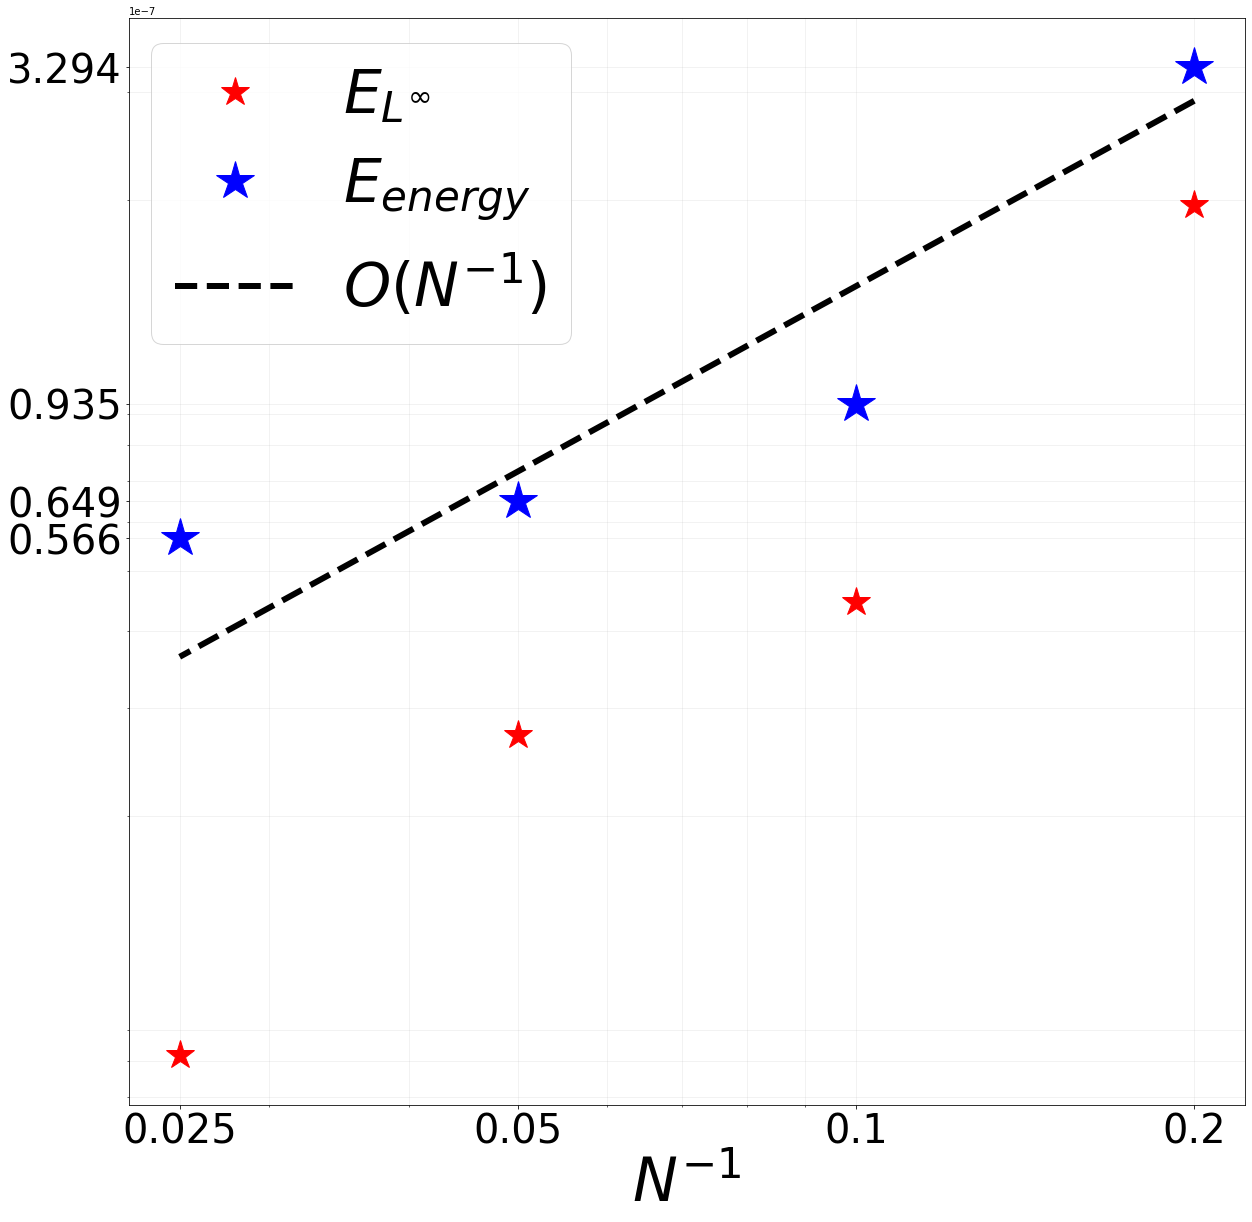

In [21]:
legend_size = 60
label_size = 40
fig_size = 20
line_width = 6
axis_name_size = 60
marker_size = 30

fig,ax = plt.subplots(figsize=(fig_size,fig_size))
h = [1/N for N in size_list]

solutions_ref = [np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]) for mesh in Meshes]
errors_L2 = [np.linalg.norm(u-u_ref)/u.shape[0] for (u, u_ref) in zip(solutions, solutions_ref)]

ax.loglog(h,errors_L0, '*', label="$E_{L^\infty}$", markersize = marker_size, color="red")
ax.loglog(h,errors_energy, '*', label="$E_{energy}$", markersize = marker_size+10, color="blue")
#ax.loglog(h,errors_energy_test, '*', label="$E_{energy_test}$", markersize = marker_size, color="green")
#ax.loglog(h,errors_L2, '*', label="$E_{L2}$", markersize = marker_size, color="green")
ax.loglog(h,h/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-1})$", color="black", linewidth= line_width )


# Customize tick formatting
#plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(h))
plt.gca().xaxis.set_minor_formatter(NullFormatter())
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(NullFormatter())

# Set the ticks at each data point
plt.xticks(h,h)
plt.yticks(errors_energy) 

#ax.get_xaxis().get_major_formatter().labelOnlyBase = False
ax.tick_params(axis='x', which='both', labelsize=label_size)
ax.tick_params(axis='y', which='both', labelsize=label_size)
ax.set_xticks(h)

#grid
ax.grid(alpha=0.2,which='both')

# legend and axis label
legend = ax.legend(prop={'size': legend_size},loc=(0.02,0.7)) 
ax.set_xlabel('$N^{-1}$',fontsize=axis_name_size)
#ax.set_ylabel('$$',fontsize=axis_name_size) 
# tick setting

#plt.show()
plt.savefig('L0_convergence.png')
ax.grid('on')

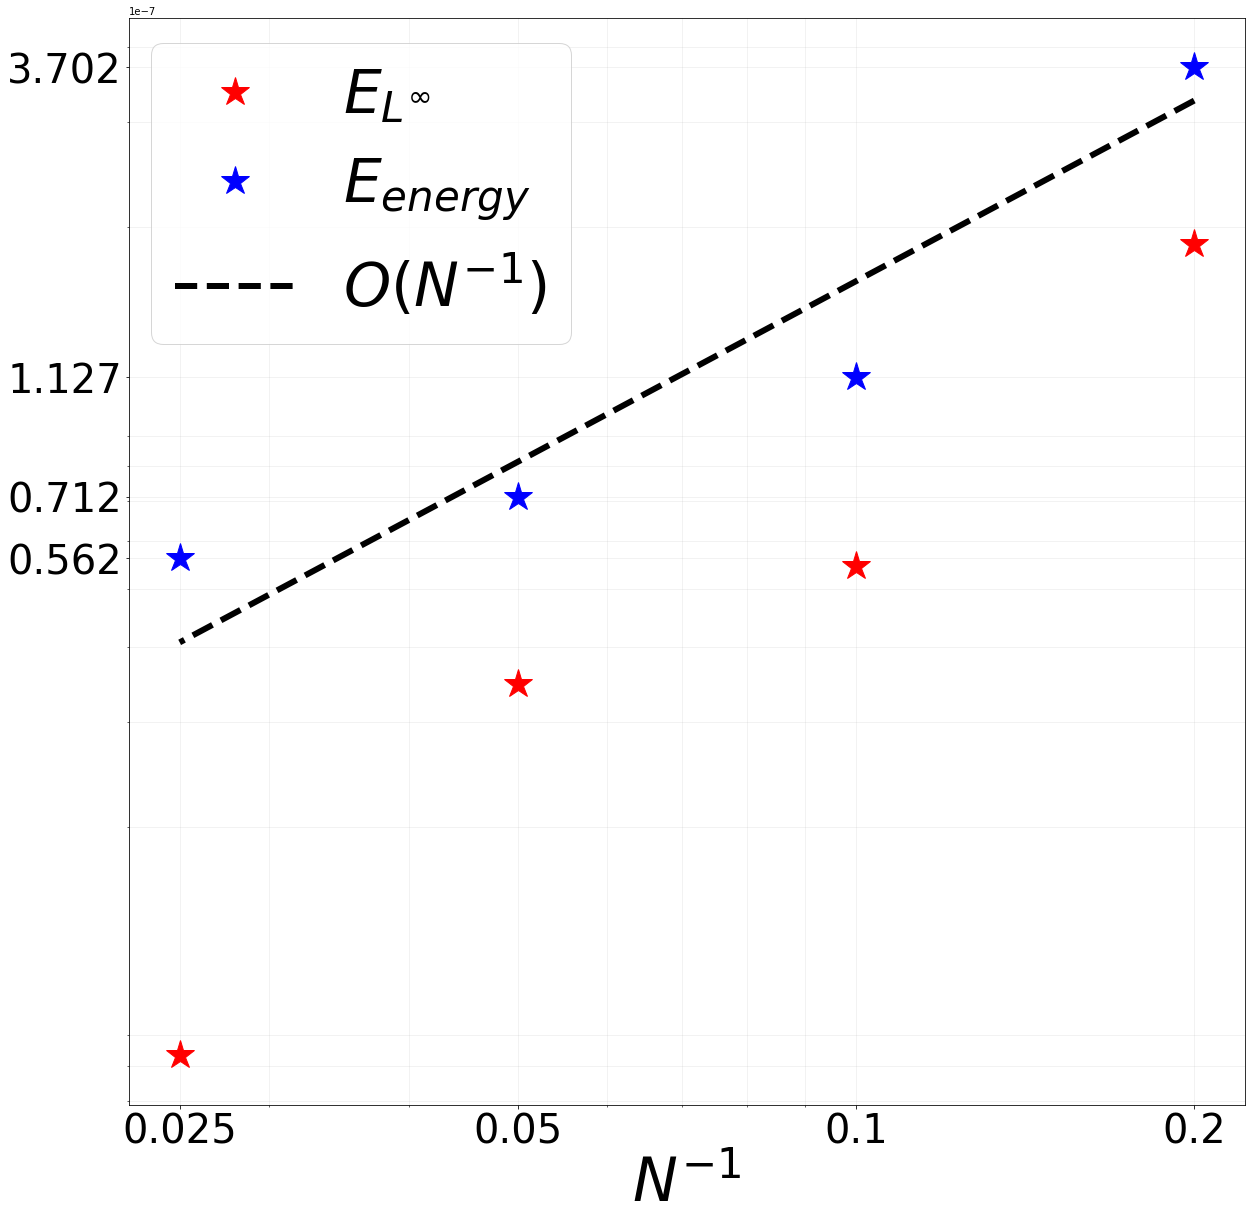

In [120]:
# RESULT OBTAINED WITH NO TRANSPOSITION!!!!!!!!!!!!!!!!

legend_size = 60
label_size = 40
fig_size = 20
line_width = 6
axis_name_size = 60
marker_size = 30

fig,ax = plt.subplots(figsize=(fig_size,fig_size))
h = [1/N for N in size_list]

solutions_ref = [np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]) for mesh in Meshes]
errors_L2 = [np.linalg.norm(u-u_ref)/u.shape[0] for (u, u_ref) in zip(solutions, solutions_ref)]

ax.loglog(h,errors_L0, '*', label="$E_{L^\infty}$", markersize = marker_size, color="red")
ax.loglog(h,errors_energy, '*', label="$E_{energy}$", markersize = marker_size, color="blue")
#ax.loglog(h,errors_L2, '*', label="$E_{L2}$", markersize = marker_size, color="green")
ax.loglog(h,h/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-1})$", color="black", linewidth= line_width )


# Customize tick formatting
#plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(h))
plt.gca().xaxis.set_minor_formatter(NullFormatter())
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(NullFormatter())

# Set the ticks at each data point
plt.xticks(h,h)
plt.yticks(errors_energy) 

#ax.get_xaxis().get_major_formatter().labelOnlyBase = False
ax.tick_params(axis='x', which='both', labelsize=label_size)
ax.tick_params(axis='y', which='both', labelsize=label_size)
ax.set_xticks(h)

#grid
ax.grid(alpha=0.2,which='both')

# legend and axis label
legend = ax.legend(prop={'size': legend_size},loc=(0.02,0.7) ) 
ax.set_xlabel('$N^{-1}$',fontsize=axis_name_size)
#ax.set_ylabel('$$',fontsize=axis_name_size) 
# tick setting

#plt.show()
plt.savefig('L0_convergence.png')
ax.grid('on')

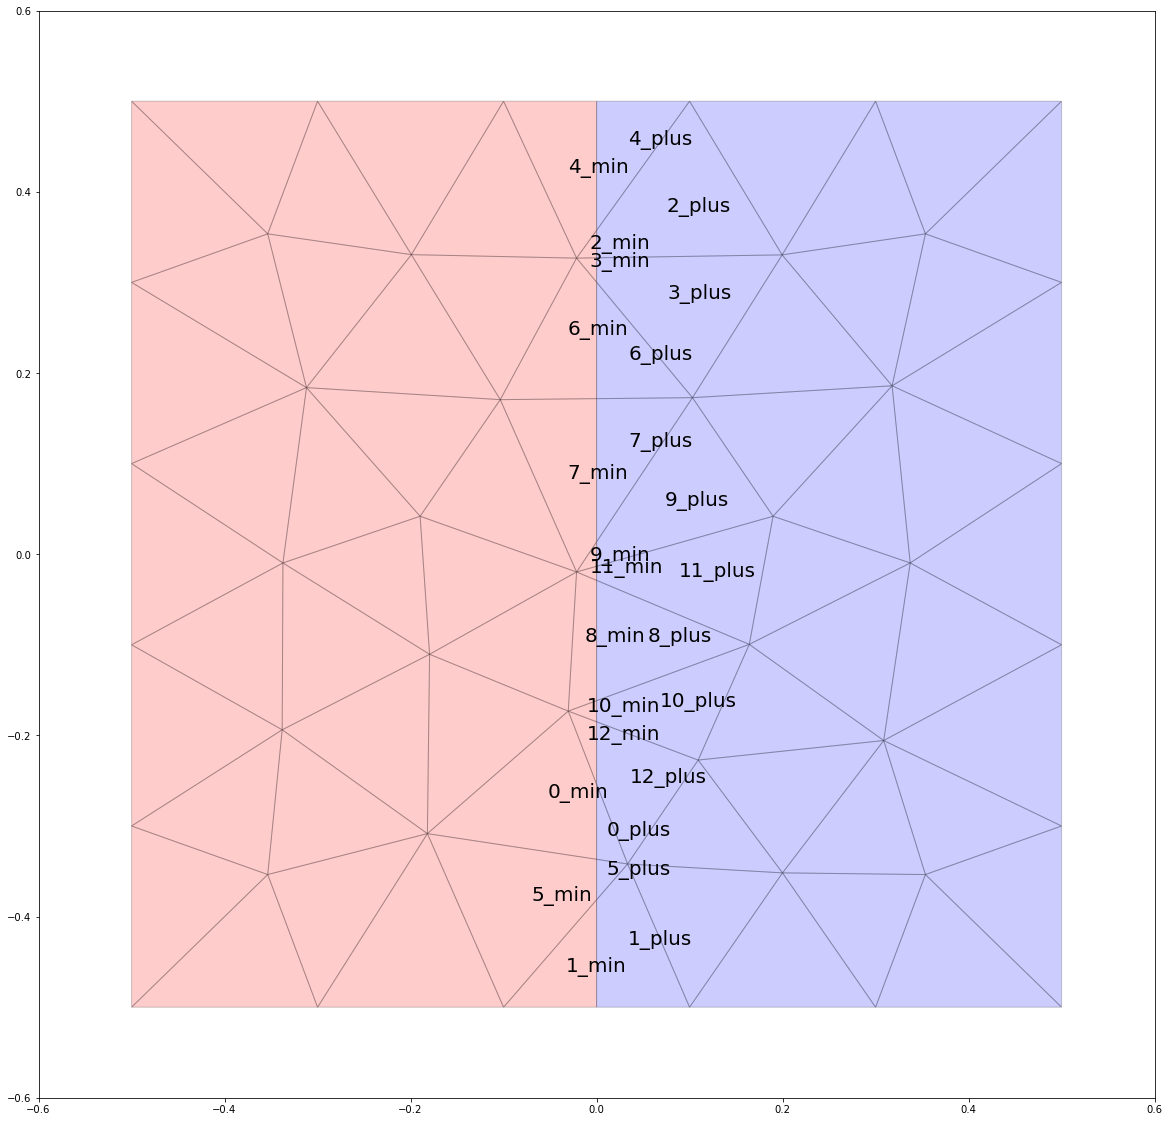

In [121]:
# CHECK MESH

def check_mesh(mesh):
    fig, ax = plt.subplots(figsize=(20,20))
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.6, 0.6)
    # trace underlying mesh 
    for ifa in range(mesh.Nfaces):
        verts = []
        if (mesh.cut_faces[ifa]!=1):
            # determine number of vertices
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
            else:
                nvert = 4
            if (mesh.cut_faces[ifa]==0):
                nvert = 3
            # determine side    
            if (mesh.side_mask[ifa]==0):
                color = 'red'
            elif (mesh.side_mask[ifa]==1):
                color = 'blue'
            else:
                color = 'green'
            for ino in range(nvert):
                p1 = mesh.coords[mesh.faces[ifa,ino],:]
                verts.append(p1[0:2])
            element = Polygon(verts, closed=True, edgecolor='black', facecolor=color, alpha=0.2)
            ax.add_patch(element)
    for (ie, couple) in enumerate(mesh.gamma_edges):
        ifa1 = couple[0]
        ifa2 = couple[1]
        text_pos_1 = ddr.barycenter(mesh, ifa1)
        text_pos_2 = ddr.barycenter(mesh, ifa2)
        text_content_1= str(ie)+"_min"
        text_content_2= str(ie)+"_plus"
        ax.text(text_pos_1[0], text_pos_1[1], text_content_1, fontsize=20, color='black')
        ax.text(text_pos_2[0], text_pos_2[1], text_content_2, fontsize=20, color='black')
        
n=0
mesh = Meshes[n]
check_mesh(mesh)

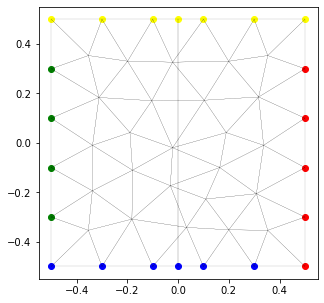

In [30]:
# CHECK BOUNDARY MASK

def visualize_bnd_points_with_dof(mesh):
    fig, ax = plt.subplots(figsize=(5,5))
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
            else:
                nvert = 4
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.1)
    # mark generated points
    for dof in range(mesh.Npoints):
        if (dof<mesh.Npoints):
            ino = dof
        else:
            ino = dof-(mesh.Npoints-mesh.Npoints_init)
        if (mesh.bnd_mask[ino]>0):
            xx = mesh.coords[ino,0]
            yy = mesh.coords[ino,1]
            if (mesh.bnd_mask[ino]==1):
                point = ax.scatter(xx,yy,color='green')
            if (mesh.bnd_mask[ino]==2):
                point = ax.scatter(xx,yy,color='blue')
            if (mesh.bnd_mask[ino]==3):
                point = ax.scatter(xx,yy,color='red')
            if (mesh.bnd_mask[ino]==4):
                point = ax.scatter(xx,yy,color='yellow')
    
visualize_bnd_points_with_dof(Meshes[n])

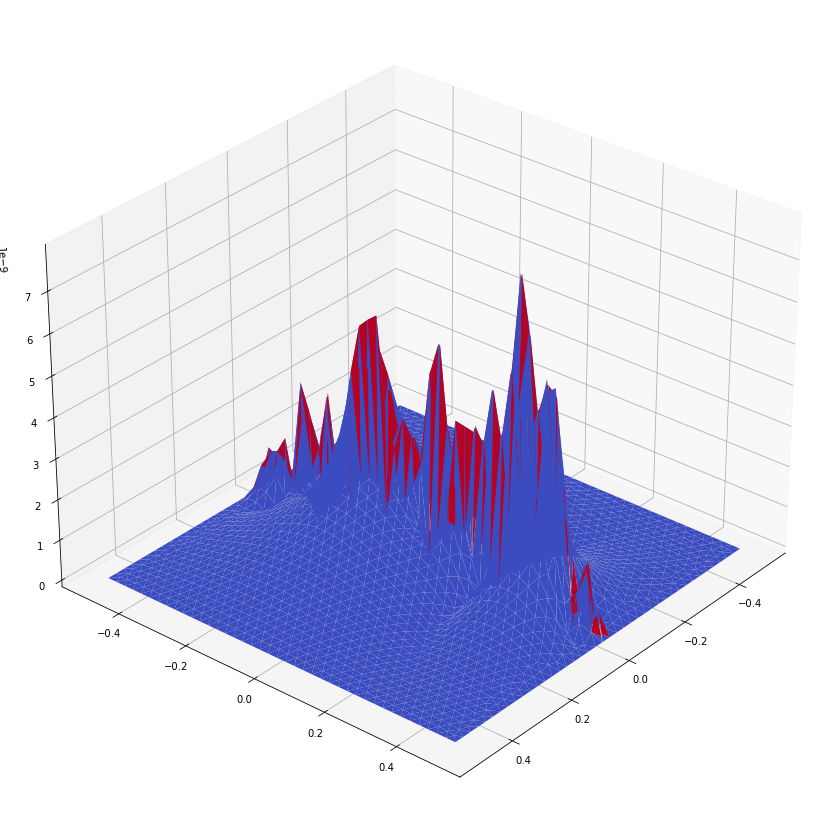

Error:  0.0


In [19]:
#VISUALIZATION OF ERROR

mesh = Meshes[n]
u = solutions[n]
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]

# define u_ref exactely as done in routine impose_bc
#def def_u_ref (mesh,u_ref, ref_sol):
#    for dof in range(mesh.Ndof):
#        if (dof<mesh.Npoints):
#            ino = dof
#        else:
#            ino = dof-(mesh.Npoints-mesh.Npoints_init)
#        if (mesh.bnd_mask[ino]>0):
#            u_ref[dof] = ref_sol(mesh,dof)
#u_ref = np.zeros(mesh.Ndof)
#def_u_ref(mesh, u_ref, ref_sol)        

ddr.plot_solution(mesh, np.abs(u_ref-u), elevation=30, azimuth=40)
print ("Error: ", ddr.calc_L0_error(mesh,u_ref,ref_sol))


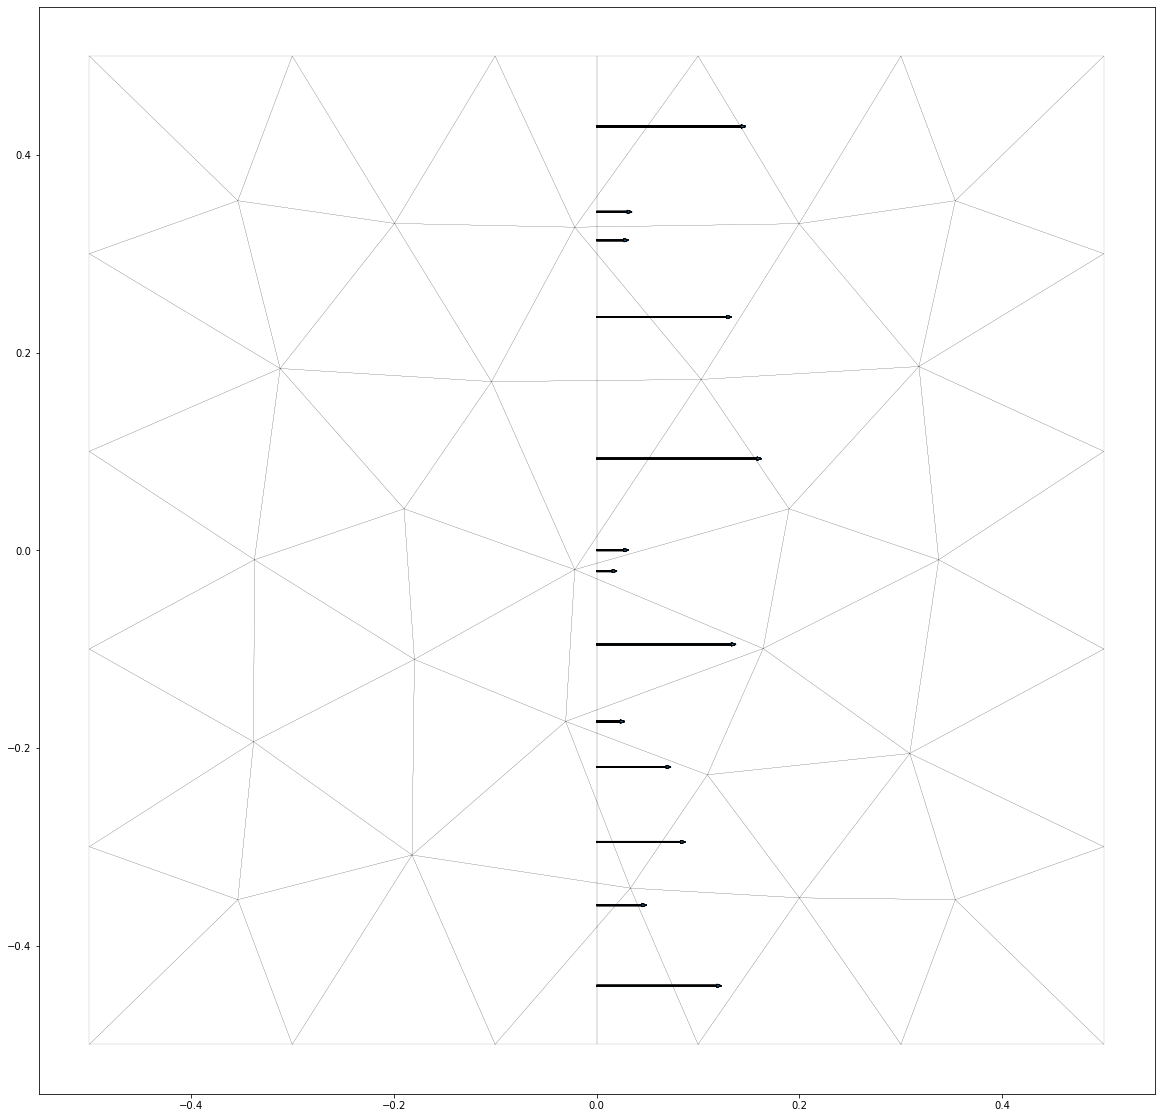

In [152]:
def assemble_M_gamma(mesh,sigma_in,sigma_ex):
    fig, ax = plt.subplots(figsize=(20,20))
    # trace underlying mesh 
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
            else:
                nvert = 4
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.1)
    # Matrix M_gamma (jump of gradient)
    M_gamma = np.zeros((mesh.Ndof,mesh.Ndof))
    for ied in range(mesh.gamma_edges.shape[0]):
        # table of dofs touched by the edge
        # 7 dofs: 3 from the triangle + 4 from the quad
        edge_dofs = np.zeros((7,2),dtype=int)
        ifa_in = mesh.gamma_edges[ied,0]
        ifa_ex = mesh.gamma_edges[ied,1]
        node_per_face_in = np.count_nonzero(mesh.faces[ifa_in,:] != -1)
        node_per_face_ex = np.count_nonzero(mesh.faces[ifa_ex,:] != -1)
        # dofs ifa_in
        for ino_in in range(node_per_face_in):
            edge_dofs[ino_in,0] = glob_idx(mesh,ifa_in, ino_in)
            edge_dofs[ino_in,1] = ifa_in
        # dofs ifa_ex
        for ino_ex in range(node_per_face_ex):
            edge_dofs[node_per_face_in+ino_ex,0] = glob_idx(mesh,ifa_ex, ino_ex)
            edge_dofs[node_per_face_in+ino_ex,1] = ifa_ex
        for idof1 in range(7):
            dof1 = edge_dofs[idof1,0] #global idx
            if (idof1<node_per_face_in): #local idx
                dof1_loc = idof1
            else:
                dof1_loc = idof1-node_per_face_in
            ifa1 = edge_dofs[idof1,1] #idx of face$
            GR1 = ddr.GR(mesh,ifa1)
            sigma1 = sigma_in*int(ifa1==ifa_in) + sigma_ex*int(ifa1==ifa_ex)
            tangent = mesh.coords[mesh.faces[ifa1,1],0:2]-mesh.coords[mesh.faces[ifa1,0],0:2]
            sign1 = int(ifa1==ifa_in)-int(ifa1==ifa_ex)
            normal = sign1*np.array([[0,1],[-1,0]])@tangent
            # add it to plot
            midpoint  = 0.5*(mesh.coords[mesh.faces[ifa1,1],0:2]+mesh.coords[mesh.faces[ifa1,0],0:2])
            ax.arrow(midpoint[0],midpoint[1],normal[0],normal[1])
            #
            mean_sigma_grad_normal = 0.5*sigma1*np.dot(GR1[:,dof1_loc],normal)
            for idof2 in range(7):
                dof2 = edge_dofs[idof2,0] #global idx
                if (idof2<node_per_face_in): #local idx
                    dof2_loc = idof2
                else:
                    dof2_loc = idof2-node_per_face_in
                ifa2 = edge_dofs[idof2,1]
                R2 = ddr.recpot(mesh,ifa2)
                ## Setting node prec as first vertex and node post as second
                ## should be indifferent though
                node_per_face_2 = np.count_nonzero(mesh.faces[ifa2,:] != -1)
                if (node_per_face_2 ==4):
                    v2A = R2[0,dof2_loc]
                    v2B = R2[1,dof2_loc]
                else:
                    v2A = R2[1,dof2_loc]
                    v2B = R2[0,dof2_loc]
                # sign (jump must be ex-in)
                sign2 = int(ifa2==ifa_ex)-int(ifa2==ifa_in)
                ## integral
                jump_of_rec = 0.5*(v2A+v2B)*sign2
                M_gamma[dof1,dof2] = M_gamma[dof1,dof2] + mean_sigma_grad_normal*jump_of_rec
    return M_gamma                                                                                  
mesh = Meshes[0]
M_gamma_test = assemble_M_gamma(mesh, sigma_min ,sigma_plus)

# TEST WITH NEUMANN CONDITIONS NOT AT THE BORDER
### it is the one that gave the good result, bu the error was driven by a bugged corner

In [10]:
def mark_bnd_points(mesh): # order to avoid overwriting corners
    # boundary mask, code:
    # 0: internal
    # 1: x=-0.5
    # 2: y=-0.5
    # 3: x= 0.5
    # 4: y= 0.5
    for ino in range(mesh.Npoints):
        if (abs(mesh.coords[ino,1]+0.5)<1e-6):
            mesh.bnd_mask[ino] = 2
        if (abs(mesh.coords[ino,1]-0.5)<1e-6):
            mesh.bnd_mask[ino] = 4
        if (abs(mesh.coords[ino,0]+0.5)<1e-6):
            mesh.bnd_mask[ino]= 1
        if (abs(mesh.coords[ino,0]-0.5)<1e-6):
            mesh.bnd_mask[ino] = 3

def impose_bc(mesh,A,b,ref_sol):
    for dof in range(mesh.Ndof):
        if (dof<mesh.Npoints):
            ino = dof
        else:
            ino = dof-(mesh.Npoints-mesh.Npoints_init)
        if (mesh.bnd_mask[ino]%2>0):
            b[dof] = ref_sol(mesh,dof)
            A[dof,:] = 0.0
            A[dof,dof] = 1
    return [A,b]


In [11]:
# CONVERGENCE STUDY: Solve problem for each mesh in the sequence and record error 
size_list = [5, 10, 20, 40]
mesh_filenames = ["square_L1_N"+str(size)+".msh" for size in size_list]
Meshes = []
G_matrices = []
G_no_sigma_matrices = []
S_matrices =[]
M_gamma_matrices = []
N_gamma_matrices = []
b_phi_vectors = []
A_matrices = []
b_vectors = []
solutions = []
errors_L0 = []
errors_energy = []
solution_filenames = ["square_L1_N"+str(size)+".vtk" for size in size_list]

for (i,N) in enumerate (size_list):
    
    # load mesh
    mesh = ddr.load_square_mesh(mesh_filenames[i]) 
    # move critical points near the interface
    ddr.move_critical_points_1D(mesh) 
    # break mesh
    ddr.break_mesh_1D(mesh) 
    # mark boundaries
    mark_bnd_points(mesh) # VERSION OF THE TEST 
    # assemble system
    G = ddr.assemble_G(mesh, sigma_min,sigma_plus) 
    G_no_sigma = ddr.assemble_G_no_sigma(mesh) 
    S = ddr.assemble_S(mesh) 
    M_gamma = ddr.assemble_M_gamma(mesh,sigma_min,sigma_plus)
    N_gamma = ddr.assemble_N_gamma(mesh)
    b_phi = ddr.assemble_b_phi(mesh,phi_datum)
    # define system, apply bc conds an solve
    A = G+S+eta*N_gamma-np.transpose(M_gamma) # system matrix
    b = eta*b_phi
    [A, b] = impose_bc(mesh, A, b, ref_sol) # THE VERSION OF THE TEST
    u = np.linalg.solve(A, b)
    # write solution
    ddr.write_VTK_file(mesh, u, solution_filenames[i])
    # calculate error
    err_L0 = ddr.calc_L0_error(mesh, u, ref_sol)
    err_energy = ddr.calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S)
    # register 
    Meshes.append(mesh)
    G_matrices.append(G)
    G_no_sigma_matrices.append(G_no_sigma)
    S_matrices.append(S)
    M_gamma_matrices.append(M_gamma)
    N_gamma_matrices.append(N_gamma)
    b_phi_vectors.append(b_phi)
    A_matrices.append(A)
    b_vectors.append(b)
    solutions.append(u)
    errors_L0.append(err_L0)
    errors_energy.append(err_energy)

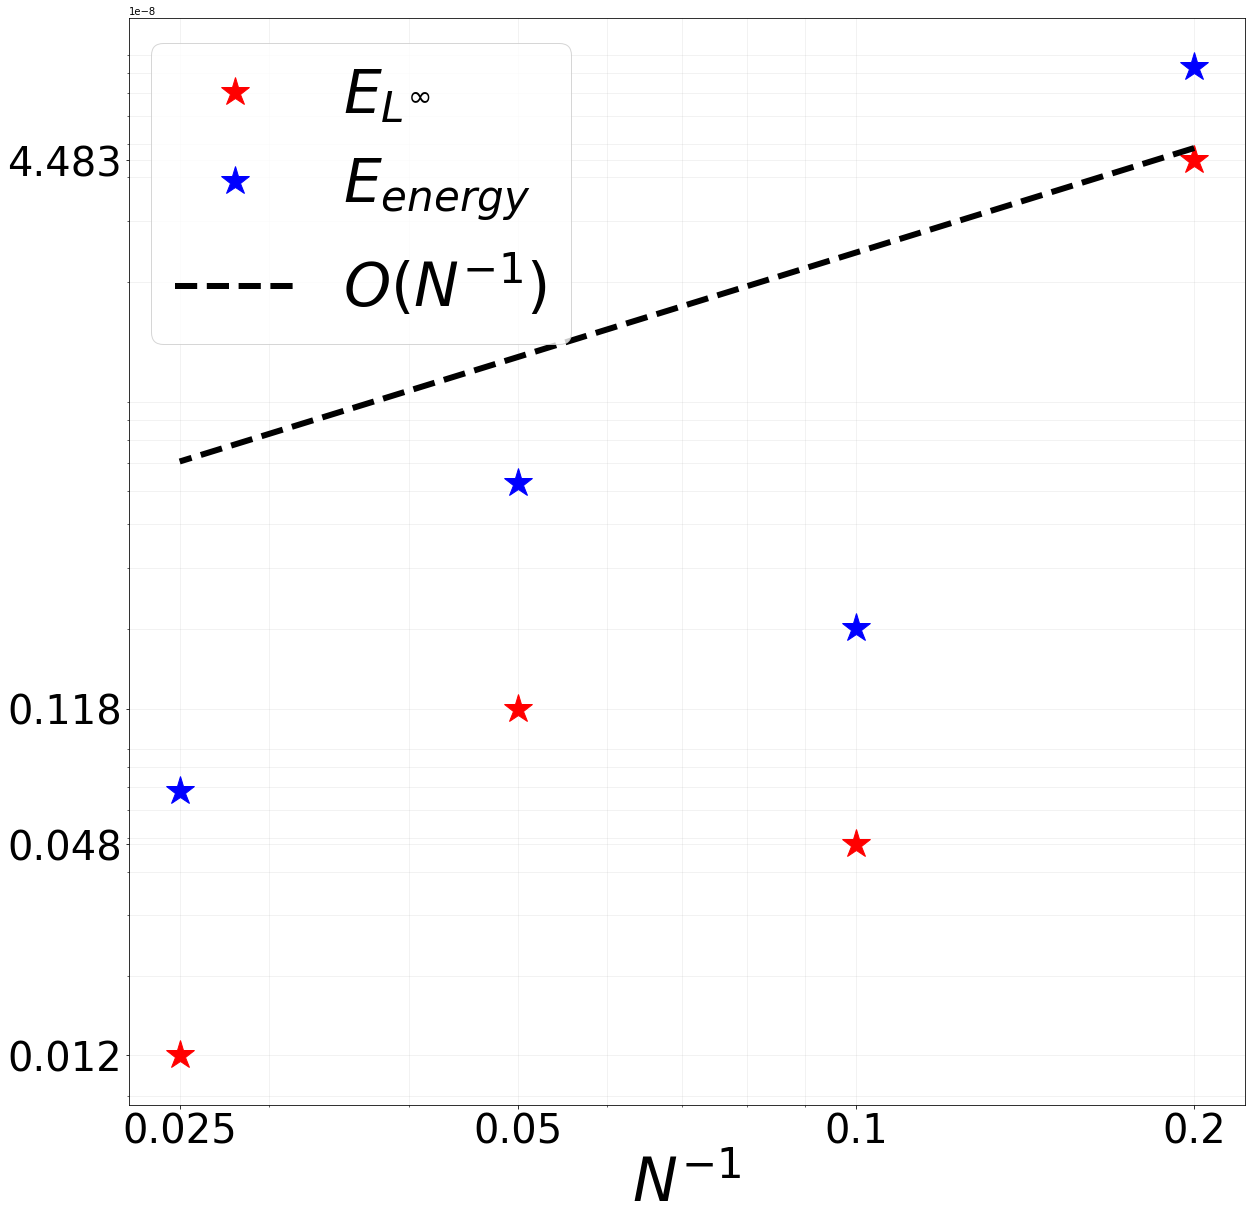

In [12]:
legend_size = 60
label_size = 40
fig_size = 20
line_width = 6
axis_name_size = 60
marker_size = 30

fig,ax = plt.subplots(figsize=(fig_size,fig_size))
h = [1/N for N in size_list]

solutions_ref = [np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]) for mesh in Meshes]
errors_L2 = [np.linalg.norm(u-u_ref)/u.shape[0] for (u, u_ref) in zip(solutions, solutions_ref)]

ax.loglog(h,errors_L0, '*', label="$E_{L^\infty}$", markersize = marker_size, color="red")
ax.loglog(h,errors_energy, '*', label="$E_{energy}$", markersize = marker_size, color="blue")
#ax.loglog(h,errors_L2, '*', label="$E_{L2}$", markersize = marker_size, color="green")
ax.loglog(h,h/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-1})$", color="black", linewidth= line_width )


# Customize tick formatting
#plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(h))
plt.gca().xaxis.set_minor_formatter(NullFormatter())
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(NullFormatter())

# Set the ticks at each data point
plt.xticks(h,h)
plt.yticks(errors_L0) 

#ax.get_xaxis().get_major_formatter().labelOnlyBase = False
ax.tick_params(axis='x', which='both', labelsize=label_size)
ax.tick_params(axis='y', which='both', labelsize=label_size)
ax.set_xticks(h)

#grid
ax.grid(alpha=0.2,which='both')

# legend and axis label
legend = ax.legend(prop={'size': legend_size},loc=(0.02,0.7) ) 
ax.set_xlabel('$N^{-1}$',fontsize=axis_name_size)
#ax.set_ylabel('$$',fontsize=axis_name_size) 
# tick setting

#plt.show()
plt.savefig('L0_convergence.png')
ax.grid('on')

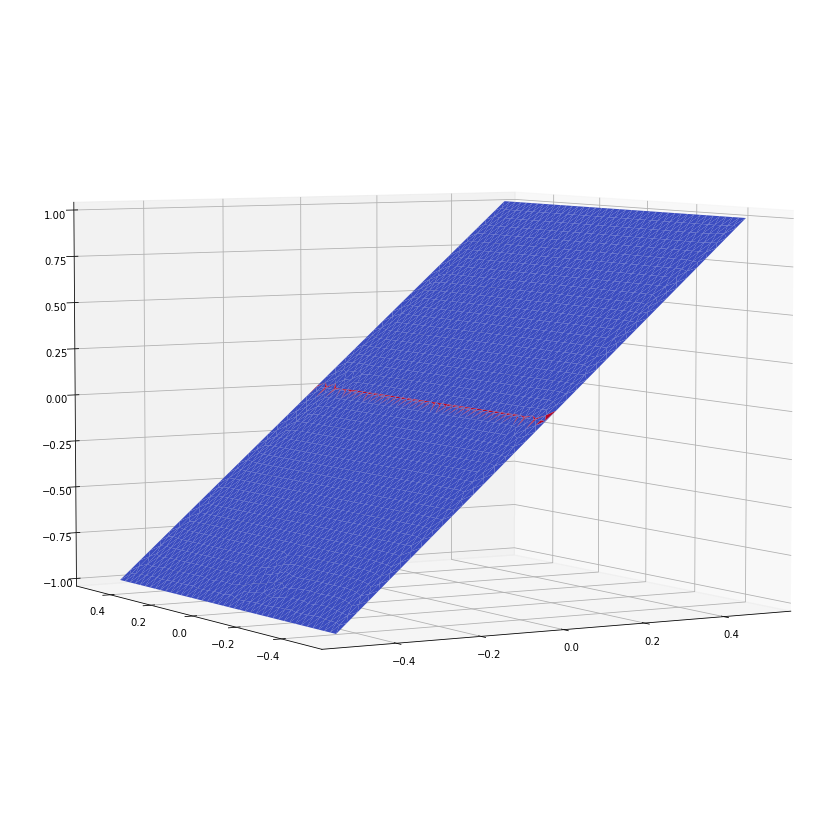

Error:  6.80727133497892e-10


In [13]:
n = 3
G_no_sigma = G_no_sigma_matrices[n]
N_gamma = N_gamma_matrices[n]
S = S_matrices[n]
ddr.plot_solution(Meshes[n], solutions[n], elevation=5, azimuth=-120)
print ("Error: ", ddr.calc_energy_error(Meshes[n],solutions[n],ref_sol, G_no_sigma, N_gamma, S))

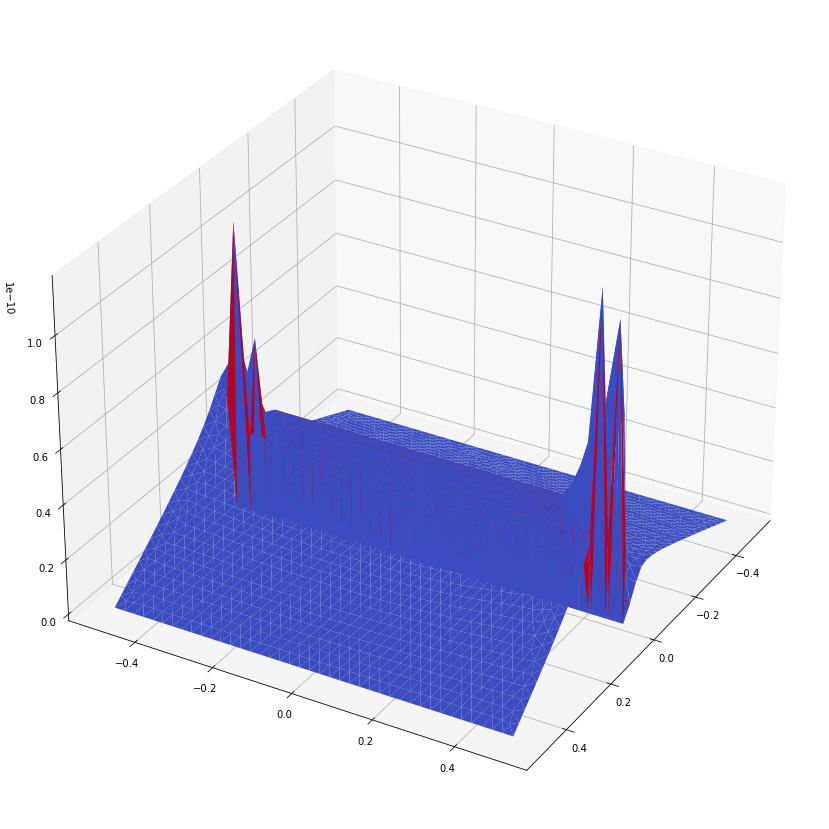

Error:  0.0


In [14]:
#VISUALIZATION OF ERROR
n = 3
mesh = Meshes[n]
u = solutions[n]
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]

# define u_ref exactely as done in routine impose_bc
#def def_u_ref (mesh,u_ref, ref_sol):
#    for dof in range(mesh.Ndof):
#        if (dof<mesh.Npoints):
#            ino = dof
#        else:
#            ino = dof-(mesh.Npoints-mesh.Npoints_init)
#        if (mesh.bnd_mask[ino]>0):
#            u_ref[dof] = ref_sol(mesh,dof)
#u_ref = np.zeros(mesh.Ndof)
#def_u_ref(mesh, u_ref, ref_sol)        

ddr.plot_solution(mesh, np.abs(u_ref-u), elevation=30, azimuth=30)
print ("Error: ", ddr.calc_L0_error(mesh,u_ref,ref_sol))

In [44]:
# SUPERBASIC DATA
L = 0.5 # semi-side
sigma_min = 1
sigma_plus = 1
phi_datum = lambda x,y: 0 # have to define it as lambda function and as real
phi_gamma = 0
g_min  = -1
g_plus =  1
    
A_min  = sigma_plus/(sigma_plus+sigma_min)*(g_plus-g_min-phi_gamma)/L
A_plus = A_min
B_min  = g_min+A_min*L
B_plus = B_min

# ref sol: expressions in x,y 
ref_sol_min = lambda x,y: A_min*(x+L)+g_min
ref_sol_plus = lambda x,y: ref_sol_min(x,y)

# wrapper ref sol that can be called by ref_sol(mesh,ino)
ref_sol = lambda mesh, dof, \
          ref_sol_min=ref_sol_min, ref_sol_plus=ref_sol_plus: \
          ddr.reference_1D_solution(mesh, dof, ref_sol_min, ref_sol_plus) 

eta = 1e12

## TEST ONLY G (OK)

In [56]:
# TESTCASE WITH NO CUT (version with only G)

# CONVERGENCE STUDY: Solve problem for each mesh in the sequence and record error 
size_list = [5, 10, 20, 40]
mesh_filenames = ["square_L1_N"+str(size)+".msh" for size in size_list]
Meshes = []
G_matrices = []
G_no_sigma_matrices = []
S_matrices =[]
M_gamma_matrices = []
N_gamma_matrices = []
b_phi_vectors = []
A_matrices = []
b_vectors = []
solutions = []
errors_L0 = []
errors_energy = []
solution_filenames = ["square_L1_N"+str(size)+".vtk" for size in size_list]

for (i,N) in enumerate (size_list):
    
    # load mesh
    mesh = ddr.load_square_mesh(mesh_filenames[i]) #OK
    # mark boundaries
    ddr.mark_bnd_points(mesh) # OK
    # assemble system
    G = ddr.assemble_G(mesh, sigma_min,sigma_plus) 
    G_no_sigma = ddr.assemble_G_no_sigma(mesh)
    S = ddr.assemble_S(mesh)
    M_gamma = ddr.assemble_M_gamma(mesh,sigma_min,sigma_plus)
    N_gamma = ddr.assemble_N_gamma(mesh)
    b_phi = ddr.assemble_b_phi(mesh,phi_datum)
    # define system, apply bc conds an solve
    #A = G+S+eta*N_gamma-np.transpose(M_gamma) # system matrix
    A = G 
    b = np.zeros(mesh.Ndof)
    [A, b] = ddr.impose_bc(mesh, A, b, ref_sol)
    u = np.linalg.solve(A, b)
    # write solution
    ddr.write_VTK_file(mesh, u, solution_filenames[i])
    # calculate error
    err_L0 = ddr.calc_L0_error(mesh, u, ref_sol)
    err_energy = ddr.calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S)
    # register 
    Meshes.append(mesh)
    G_matrices.append(G)
    G_no_sigma_matrices.append(G_no_sigma)
    S_matrices.append(S)
    M_gamma_matrices.append(M_gamma)
    N_gamma_matrices.append(N_gamma)
    b_phi_vectors.append(b_phi)
    A_matrices.append(A)
    b_vectors.append(b)
    solutions.append(u)
    errors_L0.append(err_L0)
    errors_energy.append(err_energy)

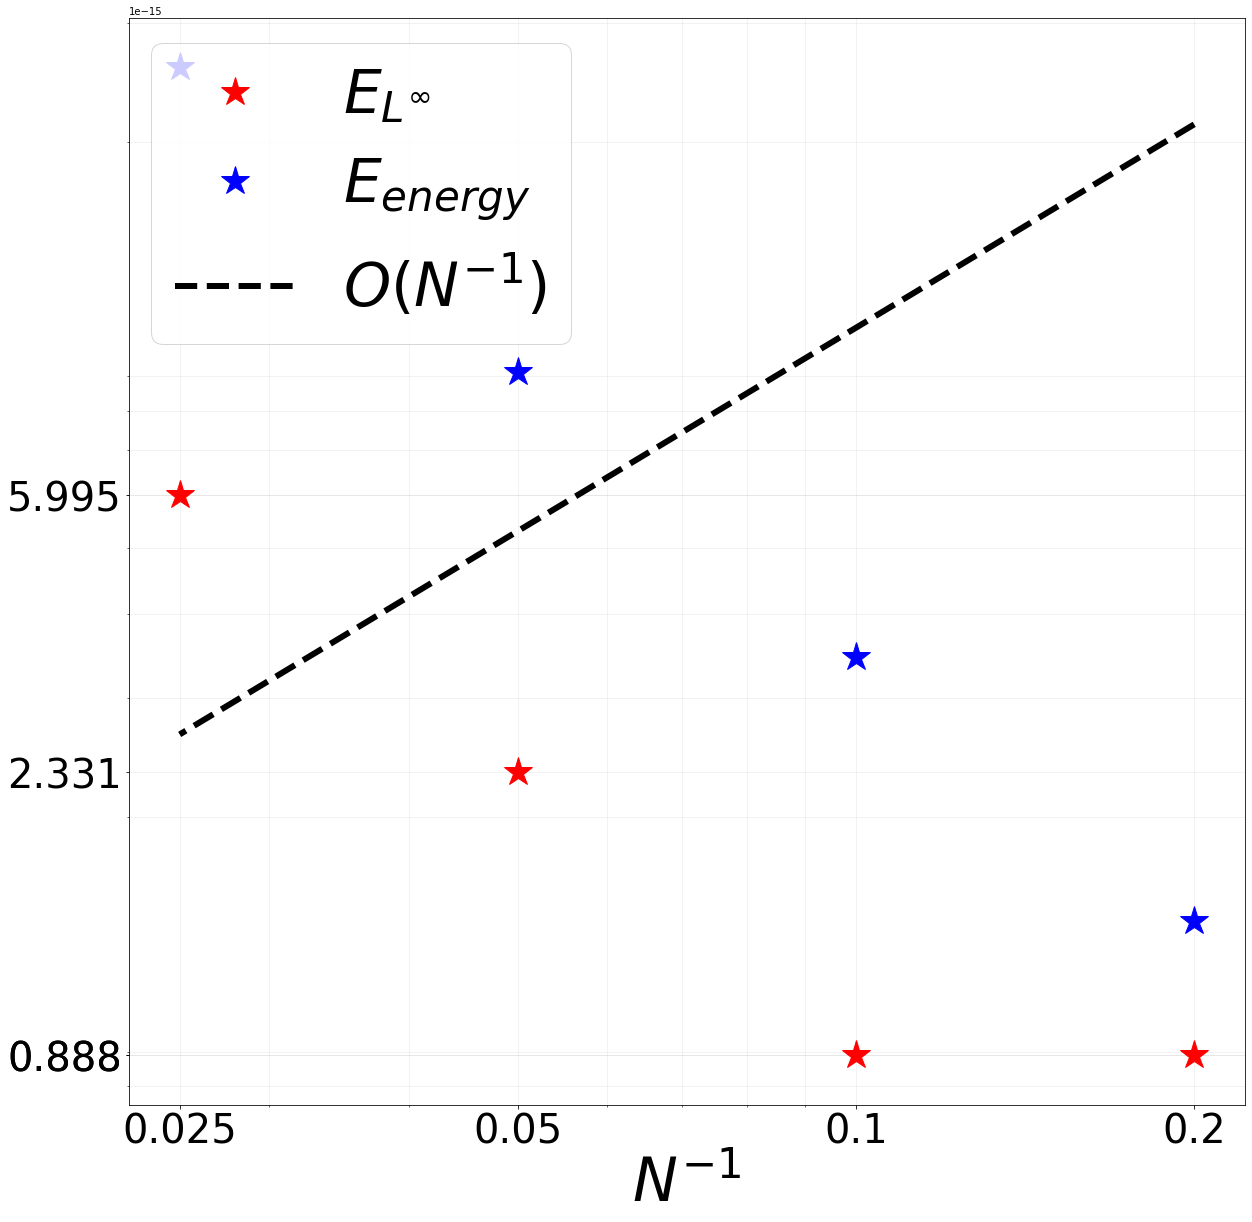

In [83]:
legend_size = 60
label_size = 40
fig_size = 20
line_width = 6
axis_name_size = 60
marker_size = 30

fig,ax = plt.subplots(figsize=(fig_size,fig_size))
h = [1/N for N in size_list]

solutions_ref = [np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]) for mesh in Meshes]
errors_L2 = [np.linalg.norm(u-u_ref)/u.shape[0] for (u, u_ref) in zip(solutions, solutions_ref)]

ax.loglog(h,errors_L0, '*', label="$E_{L^\infty}$", markersize = marker_size, color="red")
ax.loglog(h,errors_energy, '*', label="$E_{energy}$", markersize = marker_size, color="blue")
#ax.loglog(h,errors_L2, '*', label="$E_{L2}$", markersize = marker_size, color="green")
ax.loglog(h,h/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-1})$", color="black", linewidth= line_width )


# Customize tick formatting
#plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(h))
plt.gca().xaxis.set_minor_formatter(NullFormatter())
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(NullFormatter())

# Set the ticks at each data point
plt.xticks(h,h)
plt.yticks(errors_L0) 

#ax.get_xaxis().get_major_formatter().labelOnlyBase = False
ax.tick_params(axis='x', which='both', labelsize=label_size)
ax.tick_params(axis='y', which='both', labelsize=label_size)
ax.set_xticks(h)

#grid
ax.grid(alpha=0.2,which='both')

# legend and axis label
legend = ax.legend(prop={'size': legend_size},loc=(0.02,0.7) ) 
ax.set_xlabel('$N^{-1}$',fontsize=axis_name_size)
#ax.set_ylabel('$$',fontsize=axis_name_size) 
# tick setting

#plt.show()
plt.savefig('L0_convergence.png')
ax.grid('on')

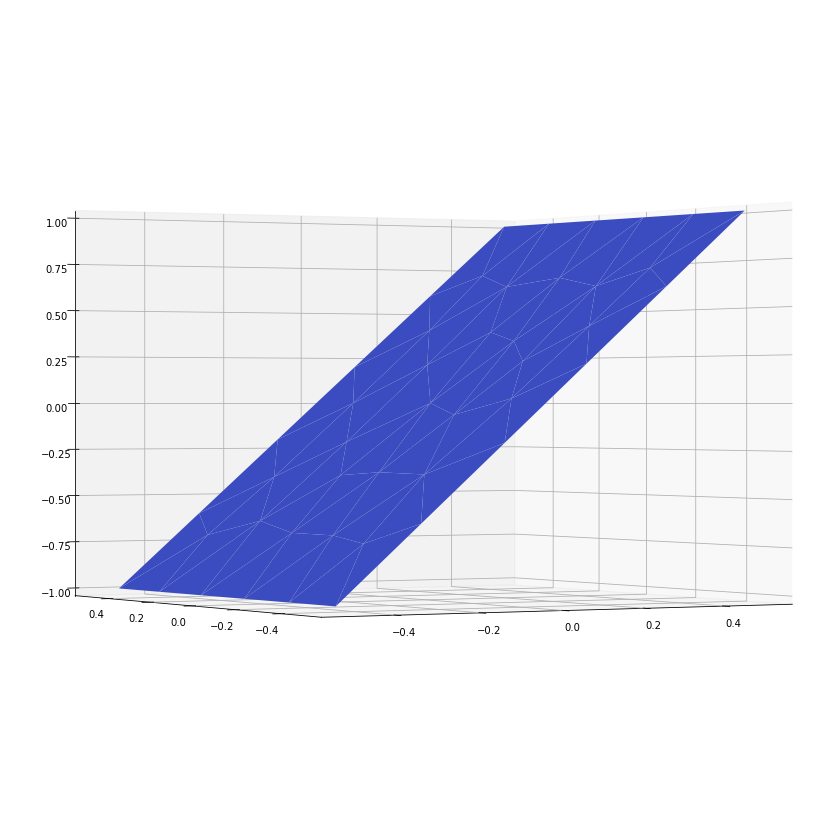

Error:  1.4058741187448304e-15


In [58]:
n = 0
G_no_sigma = G_no_sigma_matrices[n]
N_gamma = N_gamma_matrices[n]
S = S_matrices[n]
ddr.plot_solution(Meshes[n], solutions[n], elevation=0, azimuth=-120)
print ("Error: ", ddr.calc_energy_error(Meshes[n],solutions[n],ref_sol, G_no_sigma, N_gamma, S))

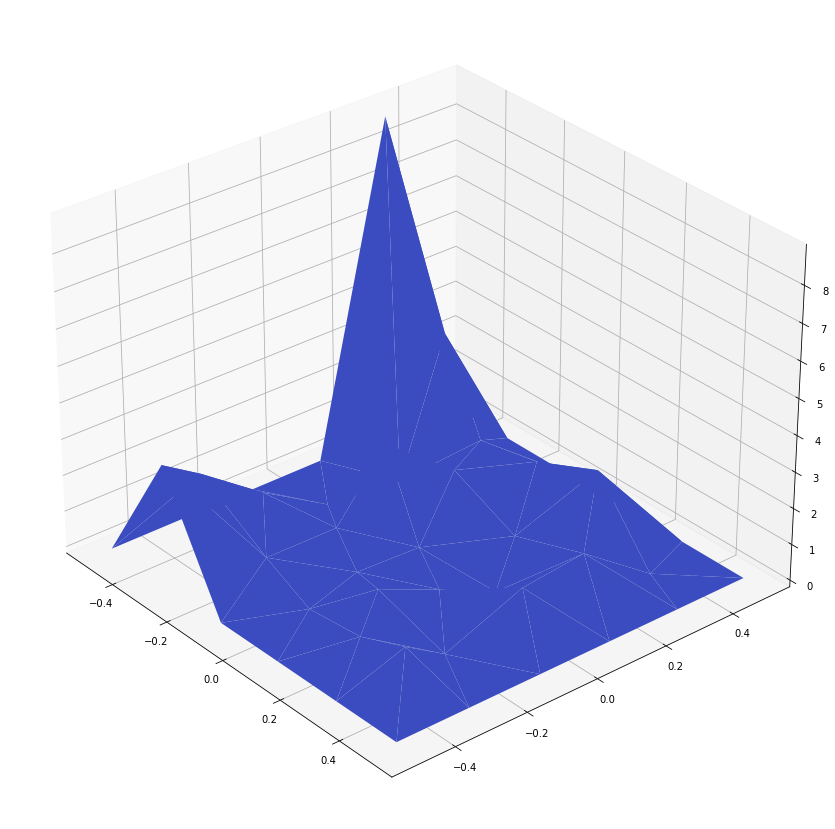

Error:  0.0


In [59]:
#VISUALIZATION OF ERROR

mesh = Meshes[n]
u = solutions[n]
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]

# define u_ref exactely as done in routine impose_bc
#def def_u_ref (mesh,u_ref, ref_sol):
#    for dof in range(mesh.Ndof):
#        if (dof<mesh.Npoints):
#            ino = dof
#        else:
#            ino = dof-(mesh.Npoints-mesh.Npoints_init)
#        if (mesh.bnd_mask[ino]>0):
#            u_ref[dof] = ref_sol(mesh,dof)
#u_ref = np.zeros(mesh.Ndof)
#def_u_ref(mesh, u_ref, ref_sol)        

ddr.plot_solution(mesh, np.abs(u_ref-u), elevation=30, azimuth=-40)
print ("Error: ", ddr.calc_L0_error(mesh,u_ref,ref_sol))

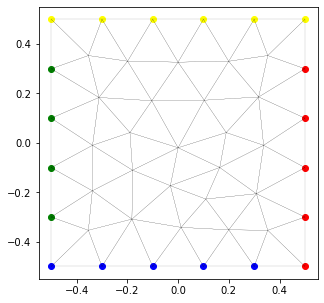

In [60]:
# CHECK BOUNDARY MASK

def visualize_bnd_points_with_dof(mesh):
    fig, ax = plt.subplots(figsize=(5,5))
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
            else:
                nvert = 4
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.1)
    # mark generated points
    for dof in range(mesh.Npoints):
        if (dof<mesh.Npoints):
            ino = dof
        else:
            ino = dof-(mesh.Npoints-mesh.Npoints_init)
        if (mesh.bnd_mask[ino]>0):
            xx = mesh.coords[ino,0]
            yy = mesh.coords[ino,1]
            if (mesh.bnd_mask[ino]==1):
                point = ax.scatter(xx,yy,color='green')
            if (mesh.bnd_mask[ino]==2):
                point = ax.scatter(xx,yy,color='blue')
            if (mesh.bnd_mask[ino]==3):
                point = ax.scatter(xx,yy,color='red')
            if (mesh.bnd_mask[ino]==4):
                point = ax.scatter(xx,yy,color='yellow')
    
visualize_bnd_points_with_dof(Meshes[n])

4 3.3306690738754696e-16 -0.6000000000011096 1.0
16 8.881784197001252e-16 -1.0 1.0


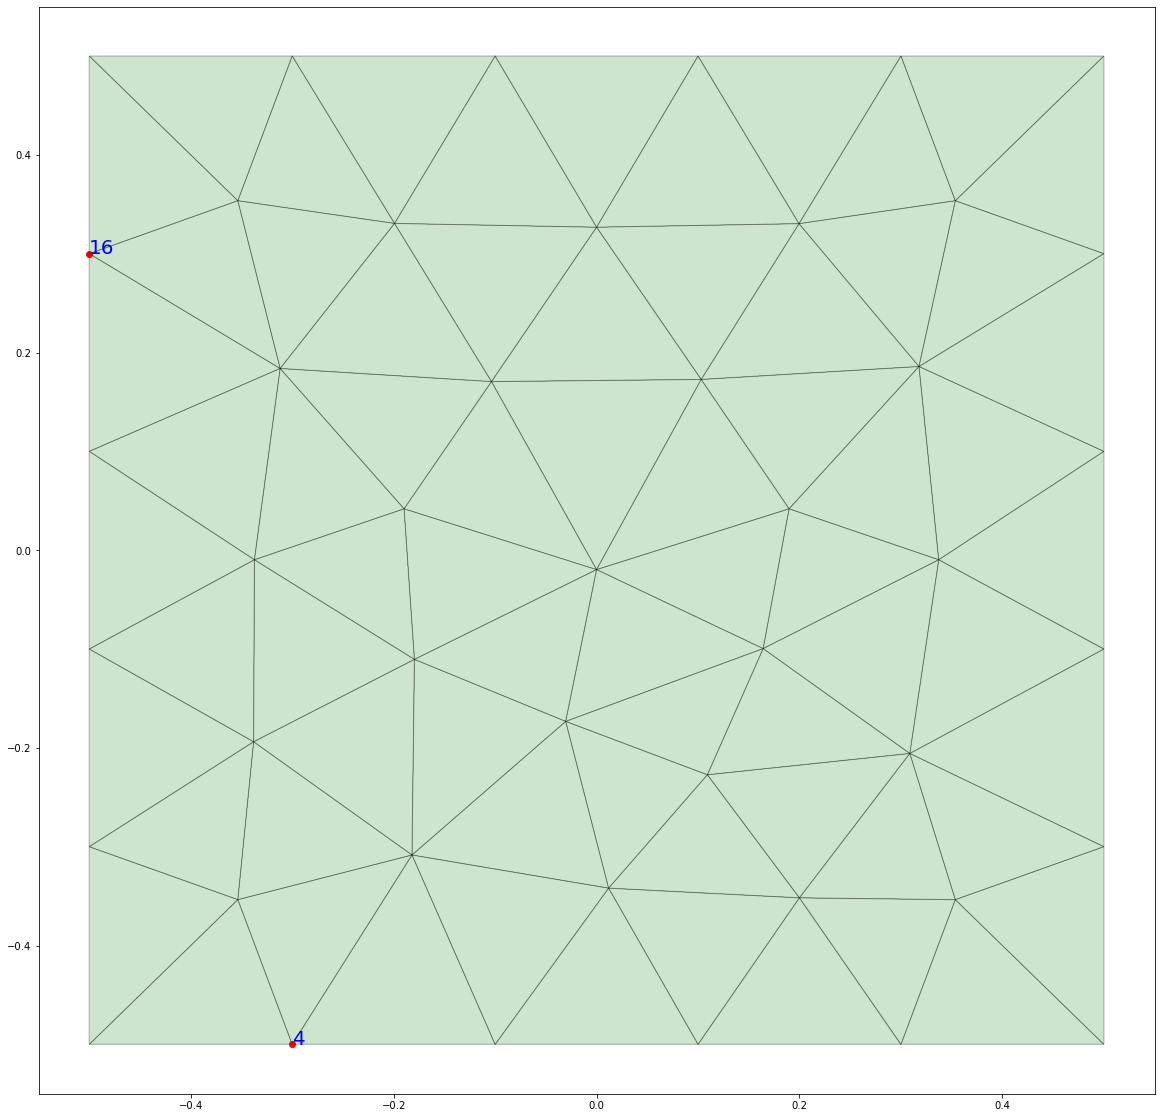

In [61]:
def check(mesh,u, u_ref, b, A):
    fig, ax = plt.subplots(figsize=(20,20))
    # trace underlying mesh 
    for ifa in range(mesh.Nfaces):
        verts = []
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
                color = 'red'
            else:
                nvert = 4
                color = 'blue'
            if (mesh.cut_faces[ifa]==0):
                nvert = 3
                color = 'green'
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               verts.append(p1[0:2])
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.1)
            element = Polygon(verts, closed=True, edgecolor='black', facecolor=color, alpha=0.2)
            ax.add_patch(element)
    # spot problematic points
    for dof in range(mesh.Ndof):
        if (dof<mesh.Npoints):
            ino = dof
        else:
            ino = dof-(mesh.Npoints-mesh.Npoints_init)
        if (mesh.bnd_mask[ino]>0):
            if (abs(u[dof]-u_ref[dof])>0):
                    print (ino, abs(u[ino]-u_ref[ino]), b[dof], A[dof,dof])
                    text_position = mesh.coords[ino,:]
                    text_content_1 = str(b[dof])
                    text_content_2 = str(ino)
                    text_content_3 = str(A[dof,dof])
                    xx = mesh.coords[ino, 0]
                    yy = mesh.coords[ino, 1]
                    #ax.text(xx, yy, text_content_1, fontsize=20, color='red')
                    ax.text(xx, yy, text_content_2, fontsize=20, color='blue')
                    point = ax.scatter(xx,yy,color='red')

b = b_vectors[n]
A = A_matrices[n]
check(mesh, u, u_ref, b, A)

In [63]:
# Check reconstruction: not used here, but notice tha

for ifa in range(mesh.Nfaces):
    print (ddr.zrecpot(mesh,ifa))

[[ 1.00000000e+00  2.20302941e-16 -2.75753212e-16]
 [ 3.22685457e-16  1.00000000e+00  9.81147743e-17]
 [-3.00245083e-16 -1.68873730e-16  1.00000000e+00]]
[[ 1.00000000e+00  7.70334456e-17  2.88158657e-16]
 [-1.38518072e-16  1.00000000e+00  1.58776869e-16]
 [ 3.62531526e-16  2.12956881e-16  1.00000000e+00]]
[[ 1.00000000e+00  4.58902121e-17  5.31176658e-17]
 [ 2.49485120e-16  1.00000000e+00  2.03353191e-16]
 [-1.93291553e-16 -1.58631661e-16  1.00000000e+00]]
[[ 1.00000000e+00  2.18318845e-16 -1.86515559e-16]
 [ 4.08275614e-16  1.00000000e+00  1.71790170e-16]
 [ 2.35348278e-17 -1.55300266e-17  1.00000000e+00]]
[[ 1.00000000e+00  6.99433277e-17  3.54033663e-16]
 [-1.33203014e-16  1.00000000e+00 -2.09549025e-16]
 [ 3.06763569e-16 -3.60352515e-16  1.00000000e+00]]
[[ 1.00000000e+00 -2.30456890e-16  2.26804487e-16]
 [-1.66434430e-16  1.00000000e+00 -1.23868258e-16]
 [ 3.98158814e-16  1.83728999e-16  1.00000000e+00]]
[[ 1.00000000e+00  2.55578933e-16 -1.81495850e-16]
 [ 4.37263033e-16  1.0000

[[ 1.00000000e+00 -1.33324843e-17 -1.86453199e-16]
 [ 6.12594089e-16  1.00000000e+00 -6.31205914e-18]
 [-2.06258381e-16 -2.68746720e-16  1.00000000e+00]]
[[ 1.00000000e+00 -6.30755304e-17  7.61407705e-18]
 [-6.34210516e-18  1.00000000e+00 -5.11552922e-17]
 [ 8.63417529e-17 -2.98844723e-17  1.00000000e+00]]


In [82]:
# test discrete operators: errors are comparable to errors in solution; they increase when reducing the size
# Conclusion: we cannot do better unless we improve the threshold for the 
# linear solver; sofar G is not the problem

n = 3
mesh = Meshes[n]

u = np.zeros(mesh.Npoints)
for ino in range(mesh.Npoints):
    x = mesh.coords[ino,0]
    y = mesh.coords[ino,0]
    u[ino] = x + y

for ifa in range(mesh.Nfaces):
    print ("Face no:", ifa)
    node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
    u_F = u[mesh.faces[ifa,0:node_per_face]]
    grad = ddr.GR(mesh,ifa)
    print("Nodal values", u_F)
    print ("Gradient: ", np.dot(grad,u_F))
    R = ddr.recpot(mesh,ifa)
    print("Reconstruction", np.dot(R,u_F))
    print ("Error gradient: ", np.linalg.norm(np.dot(grad,u_F)- np.array((2,0))))
    print ("Error rec_pot: ", np.linalg.norm(u_F- np.dot(R,u_F)))
    print ("*************")


Face no: 0
Nodal values [0.26678653 0.30927395 0.31730538]
Gradient:  [2. 0.]
Reconstruction [0.26678653 0.30927395 0.31730538]
Error gradient:  6.128431095930864e-14
Error rec_pot:  1.1657341758564144e-15
*************
Face no: 1
Nodal values [-0.90273772 -0.94957145 -0.95669873]
Gradient:  [2. 0.]
Reconstruction [-0.90273772 -0.94957145 -0.95669873]
Error gradient:  8.881784197001252e-15
Error rec_pot:  6.432590432257512e-15
*************
Face no: 2
Nodal values [0.02804113 0.05057527 0.08635577]
Gradient:  [ 2.0000000e+00 -4.4408921e-16]
Reconstruction [0.02804113 0.05057527 0.08635577]
Error gradient:  5.347542221830668e-15
Error rec_pot:  1.8631931528314482e-16
*************
Face no: 3
Nodal values [-0.87125429 -0.82239671 -0.82036271]
Gradient:  [2. 0.]
Reconstruction [-0.87125429 -0.82239671 -0.82036271]
Error gradient:  4.618527782440651e-14
Error rec_pot:  7.64281916842778e-15
*************
Face no: 4
Nodal values [-0.51794556 -0.55993646 -0.56777002]
Gradient:  [2. 0.]
Recons

Reconstruction [-0.82013496 -0.82239671 -0.87090249]
Error gradient:  7.105427357601002e-14
Error rec_pot:  1.4475537224895361e-15
*************
Face no: 50
Nodal values [-0.325      -0.38234825 -0.35      ]
Gradient:  [2.00000000e+00 1.77635684e-15]
Reconstruction [-0.325      -0.38234825 -0.35      ]
Error gradient:  1.96205025865255e-14
Error rec_pot:  3.640532860076283e-15
*************
Face no: 51
Nodal values [-0.95669873 -0.94957145 -0.90179073]
Gradient:  [2. 0.]
Reconstruction [-0.95669873 -0.94957145 -0.90179073]
Error gradient:  7.105427357601002e-15
Error rec_pot:  2.1210781103223385e-15
*************
Face no: 52
Nodal values [-0.8173641  -0.77050807 -0.81988982]
Gradient:  [ 2.00000000e+00 -1.11022302e-15]
Reconstruction [-0.8173641  -0.77050807 -0.81988982]
Error gradient:  5.685425984875427e-14
Error rec_pot:  3.1985215122904828e-15
*************
Face no: 53
Nodal values [-0.73737351 -0.69274107 -0.73384272]
Gradient:  [2.0000000e+00 4.4408921e-15]
Reconstruction [-0.737

Error rec_pot:  8.397426353102003e-15
*************
Face no: 104
Nodal values [-0.81040826 -0.79750577 -0.7718524 ]
Gradient:  [2. 0.]
Reconstruction [-0.81040826 -0.79750577 -0.7718524 ]
Error gradient:  1.4210854715202004e-14
Error rec_pot:  5.407139474782739e-15
*************
Face no: 105
Nodal values [-0.09000342 -0.07158353 -0.12003632]
Gradient:  [ 2.00000000e+00 -2.22044605e-16]
Reconstruction [-0.09000342 -0.07158353 -0.12003632]
Error gradient:  4.002966042486721e-15
Error rec_pot:  5.390944523996086e-16
*************
Face no: 106
Nodal values [-1.         -0.95438474 -1.        ]
Gradient:  [2. 0.]
Reconstruction [-1.         -0.95438474 -1.        ]
Error gradient:  0.0
Error rec_pot:  4.674816816191929e-15
*************
Face no: 107
Nodal values [-1.         -0.95151194 -1.        ]
Gradient:  [2. 0.]
Reconstruction [-1.         -0.95151194 -1.        ]
Error gradient:  3.552713678800501e-14
Error rec_pot:  4.265337574760008e-15
*************
Face no: 108
Nodal values [-1. 

Reconstruction [-0.9058951  -0.86292072 -0.91026528]
Error gradient:  2.1390168887322673e-14
Error rec_pot:  4.697175049207787e-15
*************
Face no: 160
Nodal values [-0.81925973 -0.81944635 -0.86539281]
Gradient:  [2. 0.]
Reconstruction [-0.81925973 -0.81944635 -0.86539281]
Error gradient:  5.3290705182007514e-14
Error rec_pot:  5.505407804403645e-15
*************
Face no: 161
Nodal values [-1.         -0.94957145 -0.95669873]
Gradient:  [2. 0.]
Reconstruction [-1.         -0.94957145 -0.95669873]
Error gradient:  1.0658141036401503e-14
Error rec_pot:  6.528640041021009e-15
*************
Face no: 162
Nodal values [-0.95669873 -0.94957145 -1.        ]
Gradient:  [2. 0.]
Reconstruction [-0.95669873 -0.94957145 -1.        ]
Error gradient:  3.552713678800501e-15
Error rec_pot:  4.168883761650163e-15
*************
Face no: 163
Nodal values [-0.47381851 -0.51795133 -0.47250575]
Gradient:  [2.00000000e+00 2.22044605e-15]
Reconstruction [-0.47381851 -0.51795133 -0.47250575]
Error gradie

Reconstruction [-0.86685329 -0.90776843 -0.91374487]
Error gradient:  7.944109290391274e-15
Error rec_pot:  2.7035697373913694e-15
*************
Face no: 221
Nodal values [-0.86539281 -0.81944635 -0.86685329]
Gradient:  [2. 0.]
Reconstruction [-0.86539281 -0.81944635 -0.86685329]
Error gradient:  7.105427357601002e-15
Error rec_pot:  2.3629761096480587e-15
*************
Face no: 222
Nodal values [0.02583368 0.0550021  0.075     ]
Gradient:  [2. 0.]
Reconstruction [0.02583368 0.0550021  0.075     ]
Error gradient:  4.6629367034256575e-15
Error rec_pot:  6.664589960562512e-17
*************
Face no: 223
Nodal values [0.02804113 0.0550021  0.00097263]
Gradient:  [2. 0.]
Reconstruction [0.02804113 0.0550021  0.00097263]
Error gradient:  1.1102230246251565e-15
Error rec_pot:  1.4206805426684334e-16
*************
Face no: 224
Nodal values [0.075      0.09633842 0.12983212]
Gradient:  [2. 0.]
Reconstruction [0.075      0.09633842 0.12983212]
Error gradient:  3.552713678800501e-15
Error rec_pot

...

Reconstruction [-0.77427319 -0.81395973 -0.82036271]
Error gradient:  1.1374233532693354e-14
Error rec_pot:  4.294138290686637e-15
*************
Face no: 3471
Nodal values [-0.95805784 -0.96068521 -1.        ]
Gradient:  [2. 0.]
Reconstruction [-0.95805784 -0.96068521 -1.        ]
Error gradient:  7.105427357601002e-15
Error rec_pot:  6.6046606929041506e-15
*************
Face no: 3472
Nodal values [-0.77362134 -0.73069026 -0.77050807]
Gradient:  [2.0000000e+00 4.4408921e-16]
Reconstruction [-0.77362134 -0.73069026 -0.77050807]
Error gradient:  2.842517866562357e-14
Error rec_pot:  4.319894765979208e-15
*************
Face no: 3473
Nodal values [-0.87228733 -0.83558069 -0.8255531 ]
Gradient:  [ 2.00000000e+00 -7.10542736e-15]
Reconstruction [-0.87228733 -0.83558069 -0.8255531 ]
Error gradient:  7.671311721569361e-14
Error rec_pot:  4.490574227168739e-15
*************
Face no: 3474
Nodal values [0.00069407 0.04970035 0.04759011]
Gradient:  [2. 0.]
Reconstruction [0.00069407 0.04970035 0.0

Reconstruction [-0.2        -0.17388238 -0.21911579]
Error gradient:  7.119291619286993e-15
Error rec_pot:  1.0547118733938987e-15
*************
Face no: 3529
Nodal values [0.09079202 0.04970035 0.09131264]
Gradient:  [2.00000000e+00 4.61436445e-16]
Reconstruction [0.09079202 0.04970035 0.09131264]
Error gradient:  5.349010766522216e-15
Error rec_pot:  8.092071311423672e-17
*************
Face no: 3530
Nodal values [-1.         -0.95900843 -1.        ]
Gradient:  [2. 0.]
Reconstruction [-1.         -0.95900843 -1.        ]
Error gradient:  1.4210854715202004e-14
Error rec_pot:  6.119333386465384e-15
*************
Face no: 3531
Nodal values [0.92040872 0.87361212 0.9       ]
Gradient:  [ 2.00000000e+00 -3.55271368e-15]
Reconstruction [0.92040872 0.87361212 0.9       ]
Error gradient:  4.2780337774645346e-14
Error rec_pot:  5.5942462606069484e-15
*************
Face no: 3532
Nodal values [0.85       0.87361212 0.82576926]
Gradient:  [2. 0.]
Reconstruction [0.85       0.87361212 0.82576926]

Error rec_pot:  1.0941471808815786e-15
*************
Face no: 3588
Nodal values [-0.21911579 -0.25220776 -0.275     ]
Gradient:  [ 2.00000000e+00 -1.77635684e-15]
Reconstruction [-0.21911579 -0.25220776 -0.275     ]
Error gradient:  2.892040412512553e-14
Error rec_pot:  7.771561172376096e-16
*************
Face no: 3589
Nodal values [ 0.00523541  0.01524626 -0.02521441]
Gradient:  [2. 0.]
Reconstruction [ 0.00523541  0.01524626 -0.02521441]
Error gradient:  1.3322676295501878e-15
Error rec_pot:  8.166568893253353e-17
*************
Face no: 3590
Nodal values [0.26310631 0.25651052 0.30297069]
Gradient:  [ 2.00000000e+00 -1.77635684e-15]
Reconstruction [0.26310631 0.25651052 0.30297069]
Error gradient:  4.266955553143359e-14
Error rec_pot:  9.757969893912614e-16
*************
Face no: 3591
Nodal values [0.12983212 0.175      0.15      ]
Gradient:  [2. 0.]
Reconstruction [0.12983212 0.175      0.15      ]
Error gradient:  1.865174681370263e-14
Error rec_pot:  9.860068133267014e-16
********

Error gradient:  2.1390168887322673e-14
Error rec_pot:  1.2707083321416676e-15
*************
Face no: 3647
Nodal values [-0.84849344 -0.81040826 -0.81373644]
Gradient:  [ 2.00000000e+00 -3.55271368e-15]
Reconstruction [-0.84849344 -0.81040826 -0.81373644]
Error gradient:  7.944109290391274e-15
Error rec_pot:  2.79326464745136e-15
*************
Face no: 3648
Nodal values [0.25  0.275 0.3  ]
Gradient:  [ 2.00000000e+00 -3.55271368e-15]
Reconstruction [0.25  0.275 0.3  ]
Error gradient:  2.776179216839087e-14
Error rec_pot:  2.9057317281871776e-15
*************
Face no: 3649
Nodal values [ 0.00104783 -0.04539138 -0.04180991]
Gradient:  [2. 0.]
Reconstruction [ 0.00104783 -0.04539138 -0.04180991]
Error gradient:  8.43769498715119e-15
Error rec_pot:  5.419449386414209e-17
*************
Face no: 3650
Nodal values [-0.55  -0.525 -0.5  ]
Gradient:  [ 2.00000000e+00 -3.55271368e-15]
Reconstruction [-0.55  -0.525 -0.5  ]
Error gradient:  2.6001034513542094e-14
Error rec_pot:  5.958340559489408e-

Reconstruction [0.57609505 0.55345155 0.52868592]
Error gradient:  1.0105835192707985e-13
Error rec_pot:  7.0610533492034146e-15
*************
Face no: 3702
Nodal values [0.52868591 0.55345123 0.57609504]
Gradient:  [2. 0.]
Reconstruction [0.52868591 0.55345123 0.57609504]
Error gradient:  6.394884621840902e-14
Error rec_pot:  6.625157643751797e-15
*************
Face no: 3703
Nodal values [-0.725      -0.69859802 -0.7448585 ]
Gradient:  [2.00000000e+00 1.77635684e-15]
Reconstruction [-0.725      -0.69859802 -0.7448585 ]
Error gradient:  7.817988420081216e-14
Error rec_pot:  1.169745225255967e-14
*************
Face no: 3704
Nodal values [0.92040872 0.96339746 0.95875086]
Gradient:  [2. 0.]
Reconstruction [0.92040872 0.96339746 0.95875086]
Error gradient:  9.237055564881302e-14
Error rec_pot:  6.524862985430919e-15
*************
Face no: 3705
Nodal values [-0.95775946 -0.96339746 -0.92049132]
Gradient:  [2. 0.]
Reconstruction [-0.95775946 -0.96339746 -0.92049132]
Error gradient:  1.42108

## TEST WITH INTERFACE BUT NO DOUBLING DOFS (ONLY G AND S)

In [97]:
# TESTCASE WITH NO CUT (version with only G and S): interface is there but ino==dof

# CONVERGENCE STUDY: Solve problem for each mesh in the sequence and record error 
size_list = [5, 10, 20, 40]
mesh_filenames = ["square_L1_N"+str(size)+".msh" for size in size_list]
Meshes = []
G_matrices = []
G_no_sigma_matrices = []
S_matrices =[]
A_matrices = []
b_vectors = []
solutions = []
errors_L0 = []
errors_energy = []
solution_filenames = ["square_L1_N"+str(size)+".vtk" for size in size_list]

# REDEFINITION OF FUNCTIONS TO MODIFY

# Redefinition of glob_idx
def glob_idx (mesh,ifa,ino):
    idx_point = mesh.faces[ifa,ino]
    return idx_point

# redefine assembling functions that use glob_idx (only copied and added .ddr where necessary)

def assemble_G(mesh,sigma_in,sigma_ex):
    # Assemble matrix G (grad-grad)
    G = np.zeros((mesh.Ndof,mesh.Ndof))
    for ifa in range(mesh.Nfaces):
        side = mesh.side_mask[ifa]
        if (mesh.cut_faces[ifa] != 1):
            node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
            GRAD = ddr.GR(mesh,ifa)
            mod_F = ddr.calc_surface(mesh,ifa)
            sigma = (1-side)*sigma_in + side*sigma_ex
            for i in range(node_per_face):
                for j in range(node_per_face):
                    glob_i = glob_idx(mesh,ifa,i)
                    glob_j = glob_idx(mesh,ifa,j)
                    G[glob_i,glob_j] = G[glob_i,glob_j] +sigma*mod_F*np.dot(GRAD[:,i],GRAD[:,j])
    return G
    
def assemble_G_no_sigma(mesh):
    # Assemble matrix G_no_sigma (to calculate H1 like norm)
    G = np.zeros((mesh.Ndof,mesh.Ndof))
    for ifa in range(mesh.Nfaces):
        side = mesh.side_mask[ifa]
        if (mesh.cut_faces[ifa] != 1):
            node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
            GRAD = ddr.GR(mesh,ifa)
            mod_F = ddr.calc_surface(mesh,ifa)
            for i in range(node_per_face):
                for j in range(node_per_face):
                    glob_i = glob_idx(mesh,ifa,i)
                    glob_j = glob_idx(mesh,ifa,j)
                    G[glob_i,glob_j] = G[glob_i,glob_j] +mod_F*np.dot(GRAD[:,i],GRAD[:,j])
    return G

def assemble_S(mesh):
    # Assemble matrix S (stabilization)
    S = np.zeros((mesh.Ndof,mesh.Ndof))
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa] != 1):
            node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
            R = ddr.recpot(mesh,ifa)
            for i in range(node_per_face):
                for j in range(node_per_face):
                    glob_i = glob_idx(mesh,ifa,i)
                    glob_j = glob_idx(mesh,ifa,j)
                    for k in range (node_per_face):
                        S[glob_i,glob_j] = S[glob_i,glob_j] + (R[k,i]-ddr.kron(i,k))*(R[k,j]-ddr.kron(j,k))
    return S

def impose_bc(mesh,A,b,ref_sol):
    for dof in range(mesh.Ndof):
        if (mesh.bnd_mask[ino]>0):
            b[dof] = ref_sol(mesh,dof)
            A[dof,:] = 0.0
            A[dof,dof] = 1
    return [A,b]


for (i,N) in enumerate (size_list):
    
    # load mesh
    mesh = ddr.load_square_mesh(mesh_filenames[i])
    ddr.move_critical_points_1D(mesh) 
    # mark boundaries
    ddr.mark_bnd_points(mesh) 
    ddr.break_mesh_1D(mesh) 
    mesh.Ndof = mesh.Npoints # CHANGED THIS TO ELIMINATE DOUBLING OF DOFS
    # assemble system
    G = assemble_G(mesh, sigma_min,sigma_plus) # USE REDEFINED FUNTION
    G_no_sigma = assemble_G_no_sigma(mesh)     # IDEM
    S = assemble_S(mesh)                       # IDEM
    N_gamma = np.zeros((mesh.Ndof, mesh.Ndof))
    M_gamma = np.zeros((mesh.Ndof, mesh.Ndof))
    # define system, apply bc conds an solve
    #A = G+S+eta*N_gamma-np.transpose(M_gamma) # system matrix
    A = G +S
    b = np.zeros(mesh.Ndof)
    [A, b] = ddr.impose_bc(mesh, A, b, ref_sol)
    u = np.linalg.solve(A, b)
    # calculate error
    err_L0 = ddr.calc_L0_error(mesh, u, ref_sol)
    err_energy = ddr.calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S)
    # register 
    Meshes.append(mesh)
    G_matrices.append(G)
    G_no_sigma_matrices.append(G_no_sigma)
    S_matrices.append(S)
    M_gamma_matrices.append(M_gamma)
    N_gamma_matrices.append(N_gamma)
    b_phi_vectors.append(b_phi)
    A_matrices.append(A)
    b_vectors.append(b)
    solutions.append(u)
    errors_L0.append(err_L0)
    errors_energy.append(err_energy)

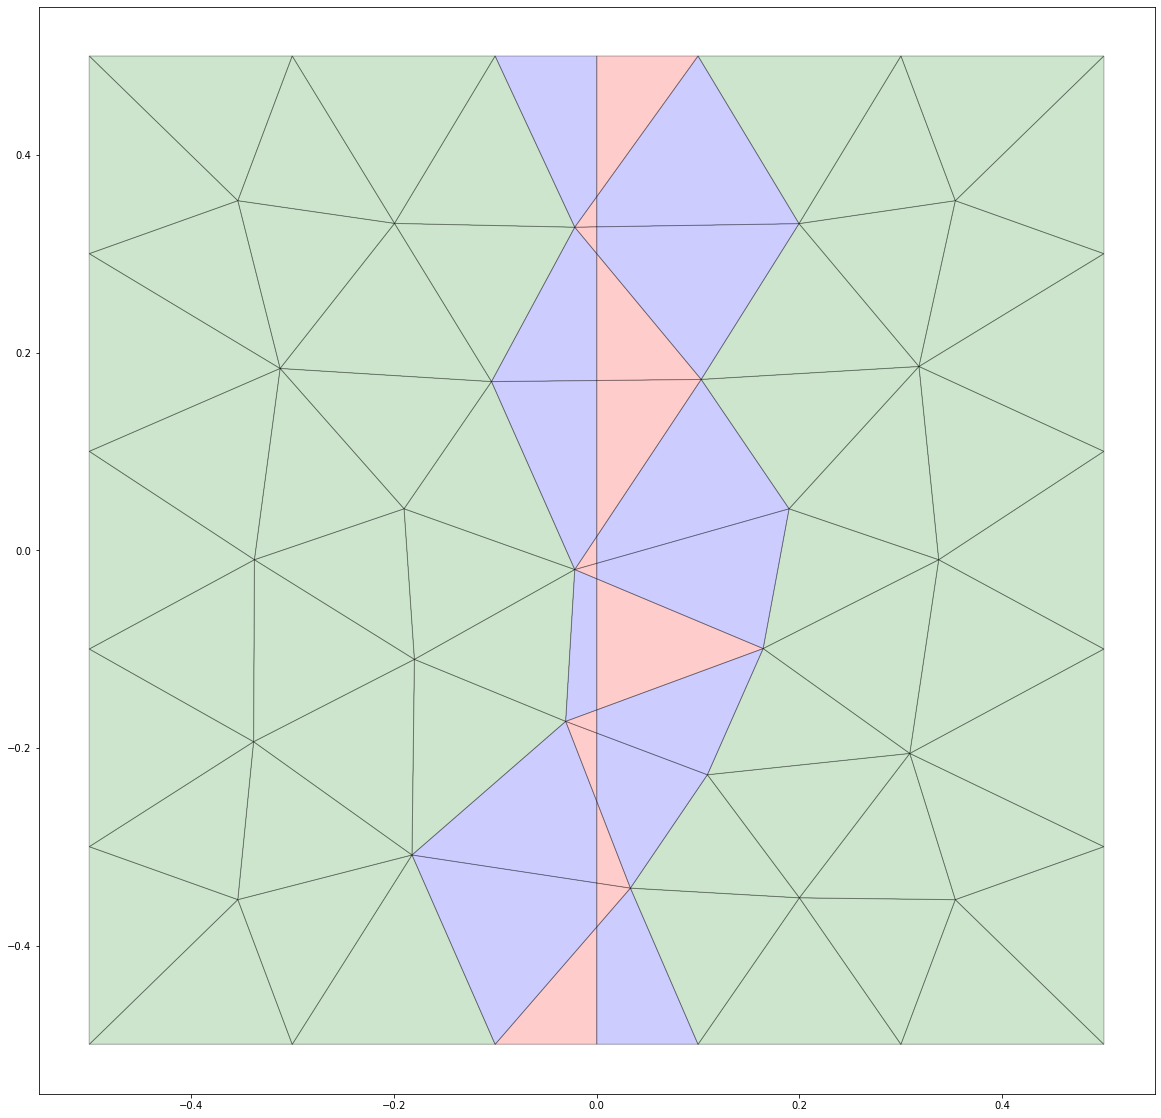

In [98]:
def check(mesh):
    fig, ax = plt.subplots(figsize=(20,20))
    # trace underlying mesh 
    for ifa in range(mesh.Nfaces):
        verts = []
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
                color = 'red'
            else:
                nvert = 4
                color = 'blue'
            if (mesh.cut_faces[ifa]==0):
                nvert = 3
                color = 'green'
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               verts.append(p1[0:2])
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.1)
            element = Polygon(verts, closed=True, edgecolor='black', facecolor=color, alpha=0.2)
            ax.add_patch(element)

mesh = Meshes[0]
check(mesh)

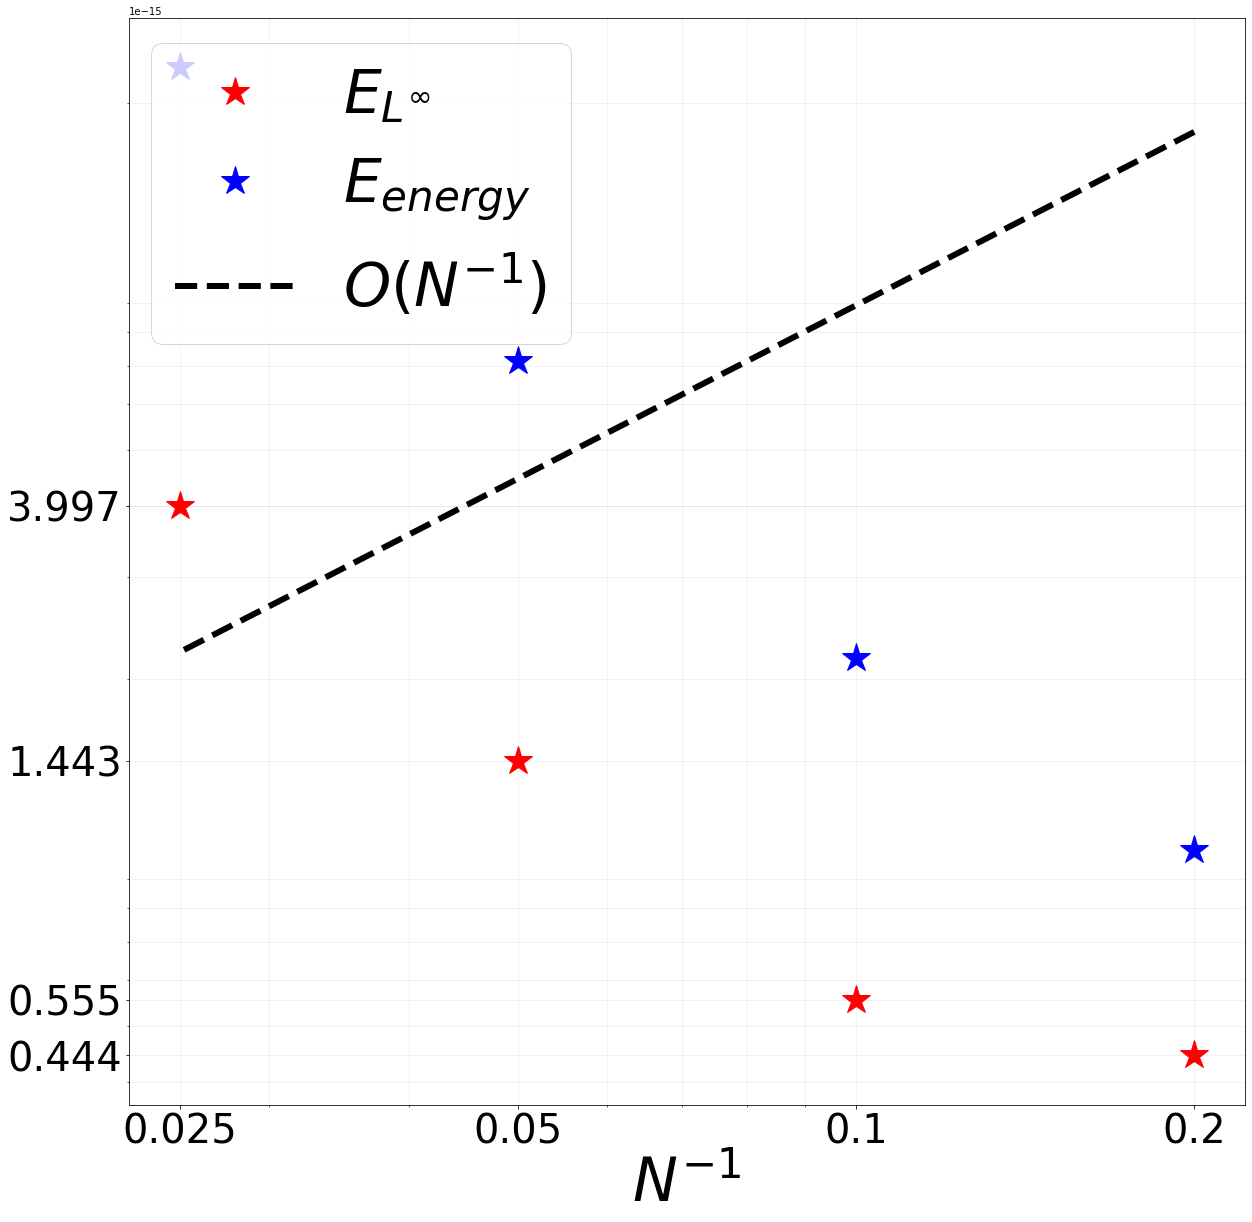

In [99]:
# Conclusion: S is OK too

legend_size = 60
label_size = 40
fig_size = 20
line_width = 6
axis_name_size = 60
marker_size = 30

fig,ax = plt.subplots(figsize=(fig_size,fig_size))
h = [1/N for N in size_list]

solutions_ref = [np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]) for mesh in Meshes]
errors_L2 = [np.linalg.norm(u-u_ref)/u.shape[0] for (u, u_ref) in zip(solutions, solutions_ref)]

ax.loglog(h,errors_L0, '*', label="$E_{L^\infty}$", markersize = marker_size, color="red")
ax.loglog(h,errors_energy, '*', label="$E_{energy}$", markersize = marker_size, color="blue")
#ax.loglog(h,errors_L2, '*', label="$E_{L2}$", markersize = marker_size, color="green")
ax.loglog(h,h/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-1})$", color="black", linewidth= line_width )


# Customize tick formatting
#plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(h))
plt.gca().xaxis.set_minor_formatter(NullFormatter())
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(NullFormatter())

# Set the ticks at each data point
plt.xticks(h,h)
plt.yticks(errors_L0) 

#ax.get_xaxis().get_major_formatter().labelOnlyBase = False
ax.tick_params(axis='x', which='both', labelsize=label_size)
ax.tick_params(axis='y', which='both', labelsize=label_size)
ax.set_xticks(h)

#grid
ax.grid(alpha=0.2,which='both')

# legend and axis label
legend = ax.legend(prop={'size': legend_size},loc=(0.02,0.7) ) 
ax.set_xlabel('$N^{-1}$',fontsize=axis_name_size)
#ax.set_ylabel('$$',fontsize=axis_name_size) 
# tick setting

#plt.show()
plt.savefig('L0_convergence.png')
ax.grid('on')

## FAILED TESTS WITH STRONG IMPOSITION OF CONTINUITY 

In [111]:
# SON'T LOOK AT THIS

# TESTCASE WITH DOUBLED DOF AT INTFACE but continuity is imposed directly instead of using N_gamma
# (matrices are G, S, and M_gamma: this is a test on M_gamma)

# CONVERGENCE STUDY: Solve problem for each mesh in the sequence and record error 
size_list = [5, 10, 20, 40]
mesh_filenames = ["square_L1_N"+str(size)+".msh" for size in size_list]
Meshes = []
G_matrices = []
G_no_sigma_matrices = []
M_gamma_matrices
S_matrices =[]
A_matrices = []
b_vectors = []
solutions = []
errors_L0 = []
errors_energy = []
solution_filenames = ["square_L1_N"+str(size)+".vtk" for size in size_list]


for (i,N) in enumerate (size_list):
    
    # load mesh
    mesh = ddr.load_square_mesh(mesh_filenames[i])
    ddr.move_critical_points_1D(mesh) 
    # mark boundaries
    ddr.mark_bnd_points(mesh) 
    ddr.break_mesh_1D(mesh) 
    # assemble system
    G = ddr.assemble_G(mesh, sigma_min,sigma_plus) 
    G_no_sigma = ddr.assemble_G_no_sigma(mesh)     
    S = ddr.assemble_S(mesh)                       
    #N_gamma = np.zeros((mesh.Ndof, mesh.Ndof)) # DON'T ADD
    M_gamma = np.zeros((mesh.Ndof, mesh.Ndof))
    # define system, apply bc conds an solve
    #A = G+S+eta*N_gamma-np.transpose(M_gamma) # system matrix
    A = G +S -np.transpose(M_gamma)
    b = np.zeros(mesh.Ndof) # no discontinuity 
    [A, b] = ddr.impose_bc(mesh, A, b, ref_sol)
    # DIRECT ENFORCEMENT OF CONTINUITY
    # solution in blocks : u = [u_0, u_1, u_2]
    n_0 = mesh.Npoints_init
    n_1 = mesh.Npoints
    n_2 = mesh.Ndof
    A_00 = A[0:n_0, 0:n_0]
    A_01 = A[0:n_0, n_0:n_1]
    A_02 = A[0:n_0, n_1:n_2]
    A_10 = A[n_0:n_1, 0:n_0]
    A_11 = A[n_0:n_1, n_0:n_1]
    A_12 = A[n_0:n_1, n_1:n_2]
    A_20 = A[n_1:n_2, 0:n_0]
    A_21 = A[n_1:n_2, n_0:n_1]
    A_22 = A[n_1:n_2, n_1:n_2]
    
    A_red = np.zeros((mesh.Ndof, mesh.Npoints))
    A_red[0:n_0,0:n_0] = A_00
    A_red[0:n_0,n_0:n_1] = A_01 - A_02
    A_red[n_0:n_1,0:n_0] = A_10
    A_red[n_0:n_1,n_0:n_1] = A_11 - A_12
    A_red[n_1:n_2,0:n_0] = A_20
    A_red[n_1:n_2,n_0:n_1] = A_21 - A_22
    
    b_red = np.zeros(mesh.Npoints)
    
    u_0_1 = np.linalg.solve(A_red, b_red)
    u_0 = u_red[0:n_0]
    u_1 = u_red[n_0:n_1]
    # compose the solution
    u = np.zeros(mesh.Ndof)
    u[0:mesh.Npoints_init] = u_0
    u[mesh.Npoints_init, mesh.Npoints] = u_1
    u[mesh.Npoints, mesh.Ndof] = u_1 # u_2 = u_1
    # calculate error
    err_L0 = ddr.calc_L0_error(mesh, u, ref_sol)
    #err_energy = ddr.calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S)
    # register 
    Meshes.append(mesh)
    G_matrices.append(G)
    G_no_sigma_matrices.append(G_no_sigma)
    S_matrices.append(S)
    M_gamma_matrices.append(M_gamma)
    N_gamma_matrices.append(N_gamma)
    b_phi_vectors.append(b_phi)
    A_matrices.append(A)
    b_vectors.append(b)
    solutions.append(u)
    errors_L0.append(err_L0)
    errors_energy.append(err_energy)

LinAlgError: Last 2 dimensions of the array must be square

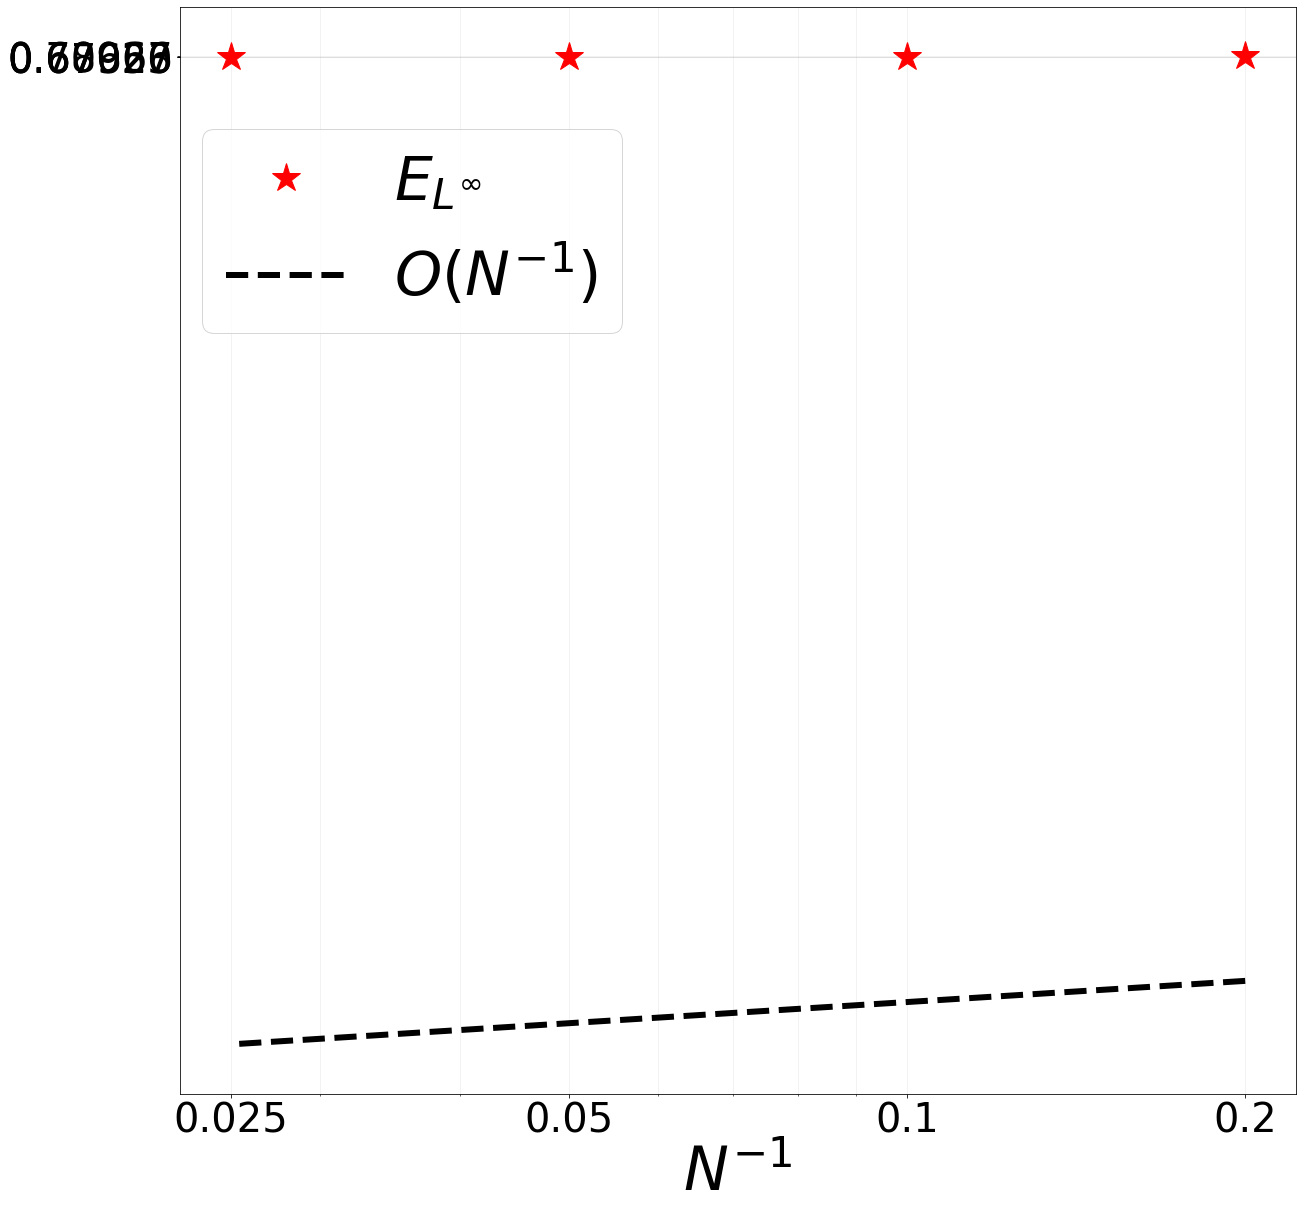

In [104]:
legend_size = 60
label_size = 40
fig_size = 20
line_width = 6
axis_name_size = 60
marker_size = 30

fig,ax = plt.subplots(figsize=(fig_size,fig_size))
h = [1/N for N in size_list]

solutions_ref = [np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]) for mesh in Meshes]
errors_L2 = [np.linalg.norm(u-u_ref)/u.shape[0] for (u, u_ref) in zip(solutions, solutions_ref)]

ax.loglog(h,errors_L0, '*', label="$E_{L^\infty}$", markersize = marker_size, color="red")
#ax.loglog(h,errors_energy, '*', label="$E_{energy}$", markersize = marker_size, color="blue")
#ax.loglog(h,errors_L2, '*', label="$E_{L2}$", markersize = marker_size, color="green")
ax.loglog(h,h/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-1})$", color="black", linewidth= line_width )


# Customize tick formatting
#plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(h))
plt.gca().xaxis.set_minor_formatter(NullFormatter())
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(NullFormatter())

# Set the ticks at each data point
plt.xticks(h,h)
plt.yticks(errors_L0) 

#ax.get_xaxis().get_major_formatter().labelOnlyBase = False
ax.tick_params(axis='x', which='both', labelsize=label_size)
ax.tick_params(axis='y', which='both', labelsize=label_size)
ax.set_xticks(h)

#grid
ax.grid(alpha=0.2,which='both')

# legend and axis label
legend = ax.legend(prop={'size': legend_size},loc=(0.02,0.7) ) 
ax.set_xlabel('$N^{-1}$',fontsize=axis_name_size)
#ax.set_ylabel('$$',fontsize=axis_name_size) 
# tick setting

#plt.show()
plt.savefig('L0_convergence.png')
ax.grid('on')

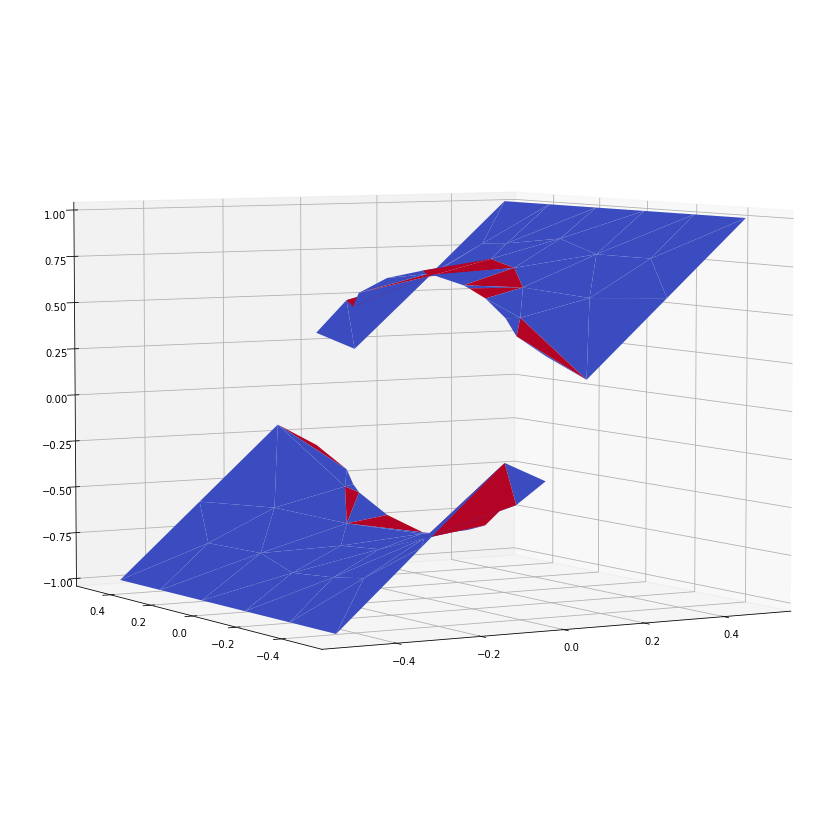

ValueError: shapes (45,45) and (73,) not aligned: 45 (dim 1) != 73 (dim 0)

In [107]:
n = 0
G_no_sigma = G_no_sigma_matrices[n]
N_gamma = N_gamma_matrices[n]
S = S_matrices[n]
ddr.plot_solution(Meshes[n], solutions[n], elevation=5, azimuth=-120)

In [140]:
# TESTCASE WITH DOUBLED DOF AT INTFACE but continuity is imposed directly instead of using N_gamma
# (matrices are G, S, and M_gamma: this is a test on M_gamma)

# CONVERGENCE STUDY: Solve problem for each mesh in the sequence and record error 
size_list = [5, 10, 20, 40]
mesh_filenames = ["square_L1_N"+str(size)+".msh" for size in size_list]
Meshes = []
G_matrices = []
G_no_sigma_matrices = []
M_gamma_matrices
S_matrices =[]
A_matrices = []
b_vectors = []
solutions = []
errors_L0 = []
errors_energy = []
solution_filenames = ["square_L1_N"+str(size)+".vtk" for size in size_list]

# don't know if this is a working way, to test: 
# overwrite lines of interface dofs to require only matching
def impose_bc(mesh,A,b,ref_sol):
    shift = mesh.Npoints -mesh.Npoints_init

    for dof in range(mesh.Ndof):
        if (dof>=mesh.Npoints_init and dof<mesh.Npoints):
            A [dof,:] = 0
            A[dof, dof] = A[dof,dof] +1
            A[dof, dof+shift] = A[dof, dof+shift] -1 
        if (dof>=mesh.Npoints_init and dof<mesh.Ndof):
            A [dof,:] = 0
            A[dof, dof] = A[dof,dof] +1
            A[dof, dof-shift] = A[dof, dof-shift] -1 
        if (dof<mesh.Npoints):
            ino = dof
        else:
            ino = dof-(mesh.Npoints-mesh.Npoints_init)
        if (mesh.bnd_mask[ino]>0):
            b[dof] = ref_sol(mesh,dof)
            A[dof,:] = 0.0
            A[dof,dof] = 1
    return [A,b]

for (i,N) in enumerate (size_list):
    
    # load mesh
    mesh = ddr.load_square_mesh(mesh_filenames[i])
    ddr.move_critical_points_1D(mesh) 
    # mark boundaries
    ddr.mark_bnd_points(mesh) 
    ddr.break_mesh_1D(mesh) 
    # assemble system
    G = ddr.assemble_G(mesh, sigma_min,sigma_plus) 
    G_no_sigma = ddr.assemble_G_no_sigma(mesh)     
    S = ddr.assemble_S(mesh)                       
    #N_gamma = np.zeros((mesh.Ndof, mesh.Ndof)) # DON'T ADD
    M_gamma = np.zeros((mesh.Ndof, mesh.Ndof))
    # define system, apply bc conds an solve
    #A = G+S+eta*N_gamma-np.transpose(M_gamma) # system matrix
    A = G +S -np.transpose(M_gamma)
    #A = G +S -M_gamma # TEST NO TRANSPOSITION
    b = np.zeros(mesh.Ndof) # no discontinuity 
    [A, b] = impose_bc(mesh, A, b, ref_sol)
    u = np.linalg.solve(A,b)
    # calculate error
    err_L0 = ddr.calc_L0_error(mesh, u, ref_sol)
    #err_energy = ddr.calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S)
    # register 
    Meshes.append(mesh)
    G_matrices.append(G)
    G_no_sigma_matrices.append(G_no_sigma)
    S_matrices.append(S)
    M_gamma_matrices.append(M_gamma)
    N_gamma_matrices.append(N_gamma)
    b_phi_vectors.append(b_phi)
    A_matrices.append(A)
    b_vectors.append(b)
    solutions.append(u)
    errors_L0.append(err_L0)
    errors_energy.append(err_energy)

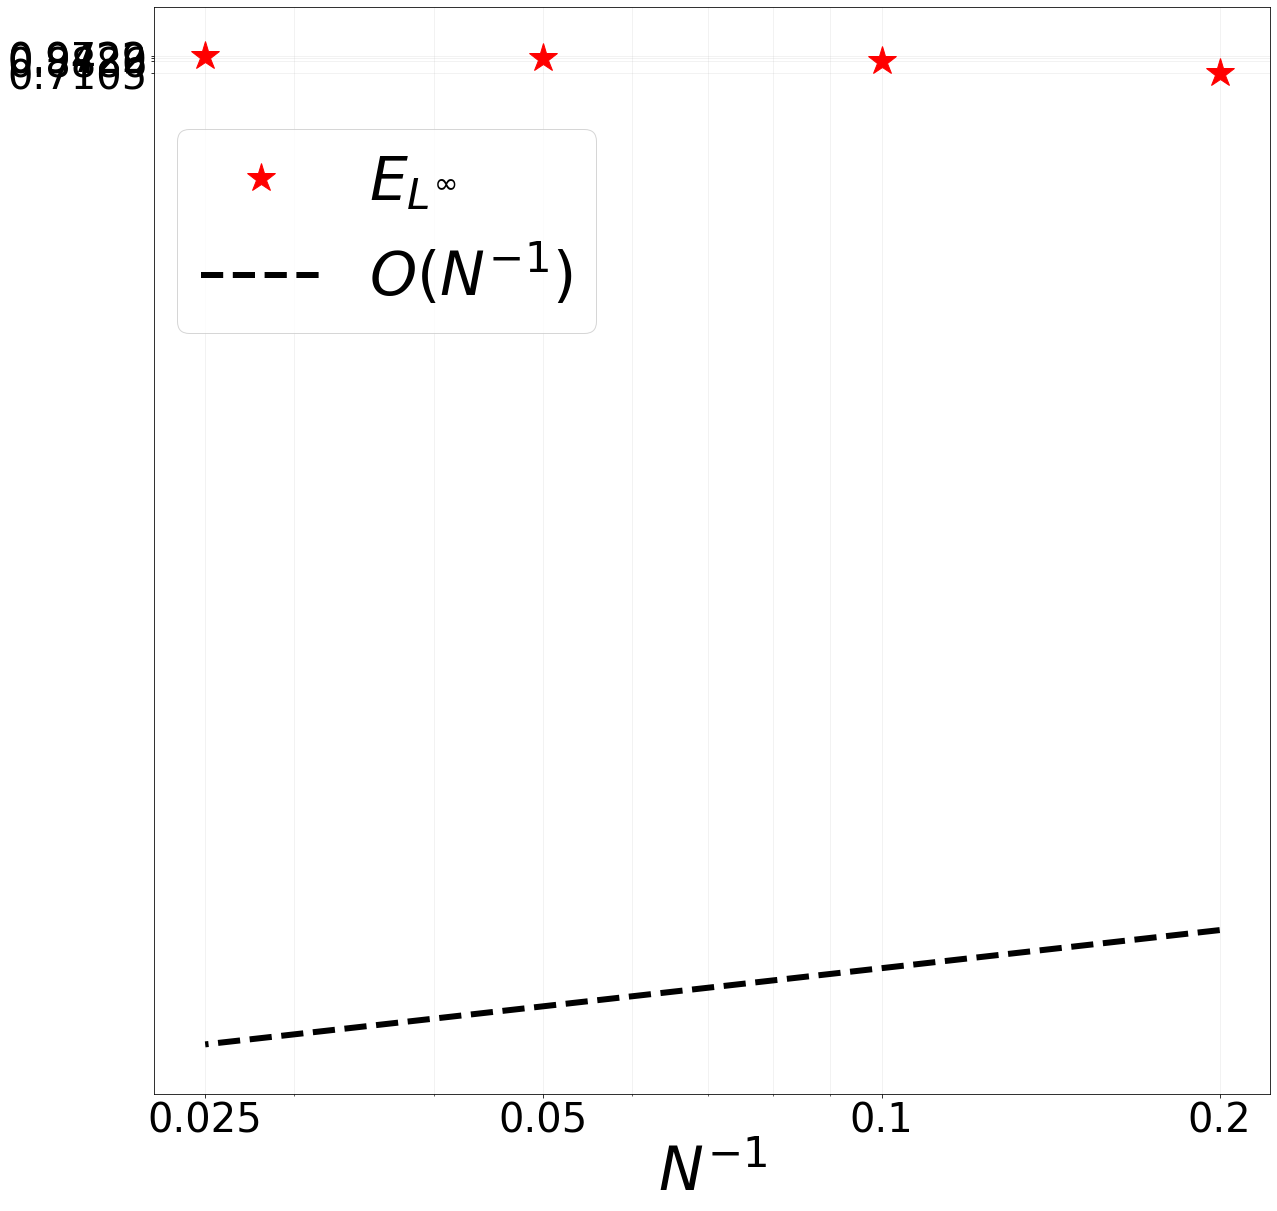

In [141]:
legend_size = 60
label_size = 40
fig_size = 20
line_width = 6
axis_name_size = 60
marker_size = 30

fig,ax = plt.subplots(figsize=(fig_size,fig_size))
h = [1/N for N in size_list]

solutions_ref = [np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]) for mesh in Meshes]
errors_L2 = [np.linalg.norm(u-u_ref)/u.shape[0] for (u, u_ref) in zip(solutions, solutions_ref)]

ax.loglog(h,errors_L0, '*', label="$E_{L^\infty}$", markersize = marker_size, color="red")
#ax.loglog(h,errors_energy, '*', label="$E_{energy}$", markersize = marker_size, color="blue")
#ax.loglog(h,errors_L2, '*', label="$E_{L2}$", markersize = marker_size, color="green")
ax.loglog(h,h/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-1})$", color="black", linewidth= line_width )


# Customize tick formatting
#plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(h))
plt.gca().xaxis.set_minor_formatter(NullFormatter())
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(NullFormatter())

# Set the ticks at each data point
plt.xticks(h,h)
plt.yticks(errors_L0) 

#ax.get_xaxis().get_major_formatter().labelOnlyBase = False
ax.tick_params(axis='x', which='both', labelsize=label_size)
ax.tick_params(axis='y', which='both', labelsize=label_size)
ax.set_xticks(h)

#grid
ax.grid(alpha=0.2,which='both')

# legend and axis label
legend = ax.legend(prop={'size': legend_size},loc=(0.02,0.7) ) 
ax.set_xlabel('$N^{-1}$',fontsize=axis_name_size)
#ax.set_ylabel('$$',fontsize=axis_name_size) 
# tick setting

#plt.show()
plt.savefig('L0_convergence.png')
ax.grid('on')

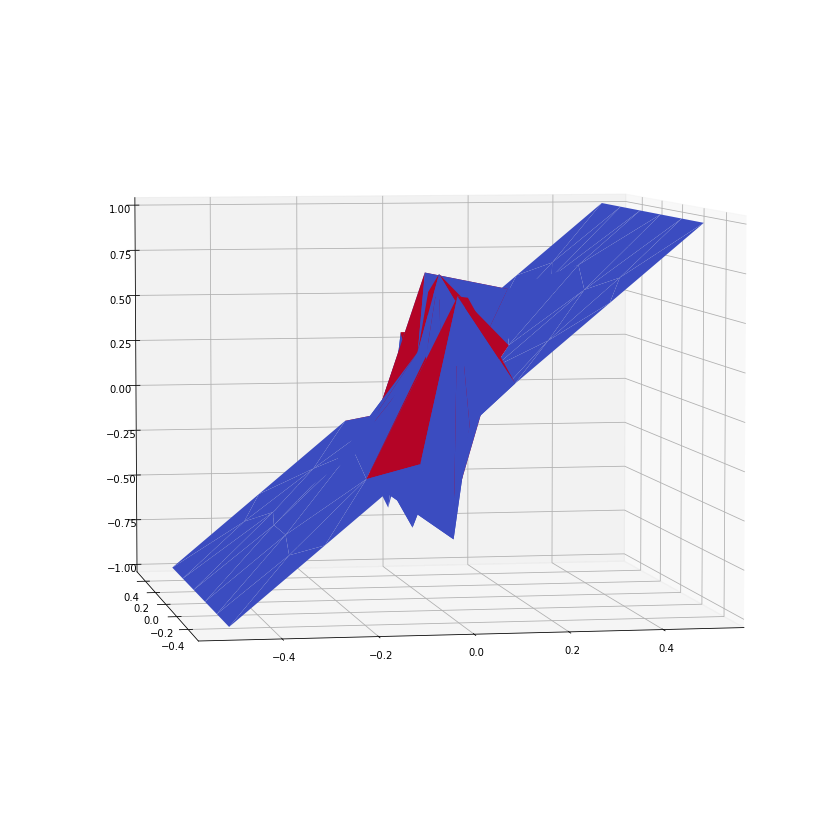

In [143]:
n = 0
G_no_sigma = G_no_sigma_matrices[n]
N_gamma = N_gamma_matrices[n]
S = S_matrices[n]
ddr.plot_solution(Meshes[n], solutions[n], elevation=5, azimuth=-100)